# 03 -- Processing: Aurora over the sites and the reference kinds

This workbook turns each site's cache into transfer functions. It applies the signs and the frame from
`decisions.csv`, scans each record for transients, builds the four references a site can be processed
against, writes one MTH5 per product with one run per kept stretch, runs Aurora, and writes an EDI and an
XML with the provenance of what was done.

Four kinds are built, and they are not alternatives to choose between here: every one of them is made, and
which of them becomes the product of record is workbook 06's question.

| word | what it is | code key | what it is for |
|---|---|---|---|
| remote site | one other site's H | `remote` | cancels the noise that is uncorrelated between the two sites; costs the variance of one more record |
| fleet stack | a coherence-weighted mean of several sites' H | `stack` | averages down each member's own noise, and needs the members aligned first |
| observatory | an INTERMAGNET one-second record | `obs` | far and quiet, and reaches the long periods |
| stack + observatory | the stack with the observatory as a member | `stack_obs` | the stack's short end with the observatory's long end |

The single station is not a kind of this package: noise in H biases it low and its error bars carry no sign
of that bias.

The frame is fixed and stated in every file: the horizontal magnetic pair of each site is turned so its mean
Hy is zero, which takes out the fluxgate's hand-compass misalignment, and the IGRF declination is recorded
and not applied. Every member of a reference is turned into its own mean-field frame before it is stacked.

The record is never cut. A mask that removes a transient is applied by giving Aurora one run per kept
stretch of at least 3,600 s: cutting and concatenating puts a step at every join, and a step common to E, H
and the reference is coherent between them, so a robust regression fits it rather than down-weighting it.

Eight checks state their failure criterion in bold above the cell and print a verdict below it. A check that
scores zero items prints UNJUDGED and counts as a failure. A criterion that is met is reported as FAIL and is
not revised afterwards.

Every step shows what it did as a figure beside the table that decided it, so a parameter can be changed for
a re-run on what the figure shows rather than on the numbers alone; each figure's caption names the
parameters that move it and what moving them does.

The 1 Hz pass is the whole record. The 10 Hz pass is not: it runs on a selection of the most coherent hours,
each selection with a random selection of the same size as its control. What the 10 Hz row reads against
the 1 Hz row is measured on this survey's own whole-record 10 Hz products over 4-32 s, printed in the last
section and written into every 10 Hz file. The 10 Hz products are not spliced onto the 1 Hz ones here, which
is workbook 06's work.

In [1]:
# ---- parameters: change these and re-run the workbook ----
SURVEY = "queensland_phase1"  # any folder under surveys/: queensland_phase2 | queensland_phase3 | victoria
RUN = "first"                 # the run name; every site of one run lands in <site>/<RUN>_<stamp>/
SITES = "all"                 # "all" | "largest" (the register's largest group) | a group name | ["Q49", "Q50"]
MAX_SITES = 0                 # 0 = every chosen site; a cap keeps an example short and names what it kept
WORK_ROOT = None              # None = survey.yaml work_root; every reference and product lands under it
SHOW = "first"                # the site every site figure is drawn for: "first" of the chosen set, or a name
KINDS = ["remote", "stack", "obs", "stack_obs"]              # the code keys of the four reference kinds
RATES = [1, 10]               # 1 is the whole record; 10 runs on the hour selection below, never the whole one
PARAMS = "kaiser20_75"        # the Aurora parameter set: kaiser20_50 | dpss4_75 | kaiser20_w512
LANES = 3                     # concurrent single-site subprocesses at 1 Hz, where a pass peaks at 2.5-4.8 GB
REDO = False                  # True remakes a product whose EDI is already on disk


In [2]:
# ---- the rule thresholds: a change here changes which reference every product was built on ----
COH_MIN = 0.5                 # the remote-site gate at 20-200 s; branches 1 and 2 need it
COH_RELAX = 0.3               # branch 3 relaxes to this where no clean candidate reaches COH_MIN
MIN_OVERLAP_DAYS = 20         # the overlap floor, taken with 0.75 x the days the target can use
STACK_CUTOFF = 0.5            # a member below this fleet coherence at 100-1000 s is refused
STACK_MAX = 8                 # the best this many members enter the stack
STACK_MIN = 2                 # fewer than this and the stack is refused: one member is a remote site renamed
EVENT_FRAC_MAX = 0.02         # clean: at most this fraction of the 600 s chunks flagged as events
BASELINE_MAX = 10             # clean: at most this multiple of the survey median baseline


In [3]:
# ---- the 10 Hz selection: which hours the short end is estimated on ----
KINDS10 = ["remote", "stack"]             # the kinds at 10 Hz; the observatory is not one of them
SITES10 = "all"               # the sites the 10 Hz lane runs over: "all" | "show" (SHOW alone) | ["Q49"]
SELECT10 = [0.05, 0.10, 0.25]  # the best fractions of the scored hours, keyed f05, f10, f25; [] = whole record
SEED = 20260916               # the draw the random control of the same size is made under, keyed r25
RUN10 = "sel10"               # the run name the selected 10 Hz products land in, <site>/<RUN10>_<stamp>/
LANES10 = 2                   # concurrent lanes at 10 Hz; a selected pass peaks at 3-10 GB, a whole one at 37


## The survey, the sites and the run

Everything below runs on `surveys/<SURVEY>/` and writes under that survey's `work_root`. The run name and
the launch stamp name one folder per site, `<site>/<RUN>_<stamp>/`, so every product of one run sits
together with the provenance of the run that made it.

In [4]:
import json
import os
import sys
import time
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

import auslamp_proc
from auslamp_proc import products as PR, survey as SV, geo, observatory
from auslamp_proc.raw import cache
from auslamp_proc.figures import process as FIGP
from auslamp_proc.process import KIND_WORD, aurora_run, edi as EDI, frame as FR, mth5_build
from auslamp_proc.process import provenance as PROV, rate as RATE, references as REF, selection as SEL
from auslamp_proc.process import transients as TR

# aurora and mth5 re-arm loguru when they are first imported, which would put tens of thousands of INFO
# lines into this workbook. Import them, then drop the sinks. The "Window is longer than the time series"
# ERROR is expected on a short run: a one-hour run holds no complete window at the deep decimation levels.
aurora_run.silence_loggers()
import aurora

pd.set_option("display.width", 230)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 400)

REPO = Path(auslamp_proc.__file__).resolve().parent.parent
sv = SV.load_survey(SURVEY)
if WORK_ROOT:
    sv.cfg["work_root"] = WORK_ROOT
WORK = Path(sv.cfg["work_root"])

def cached(site, rate=1):
    return (WORK / ("cache_%dhz" % rate) / ("%s.npz" % site)).exists()

# nothing here reads the raw tree: a site enters the run and the reference pool only where workbook 02 has
# built its cache, and the sites that have none are named rather than passed over
ALL_SITES = [s for s in sv.sites.site if cached(s)]
NO_CACHE = [s for s in sv.sites.site if not cached(s)]
CHOSEN, WHY = SV.select_sites(sv, SITES, 0)
CHOSEN = [s for s in CHOSEN if s in ALL_SITES]
if MAX_SITES and len(CHOSEN) > int(MAX_SITES):          # <- MAX_SITES caps the cached set, not the table
    WHY += "; capped at %d of %d with a cache" % (int(MAX_SITES), len(CHOSEN))
    CHOSEN = CHOSEN[:int(MAX_SITES)]
OUT = WORK / "survey"
OUT.mkdir(parents=True, exist_ok=True)
WRITTEN = []

RATES1 = [r for r in RATES if int(r) == 1]      # the whole-record lane
RATES10 = [r for r in RATES if int(r) == 10]    # the selection lane; a 10 Hz pass is never the whole record
SHOW = CHOSEN[0] if str(SHOW).lower() == "first" else str(SHOW)
if SHOW not in CHOSEN:
    SHOW = CHOSEN[0]
# the sites the 10 Hz lane is asked for, known from the parameters alone so the reference store builds for
# them and not for every chosen site; which of them carry a selected hour is settled in that section
ASK10 = (CHOSEN if str(SITES10).lower() == "all"
         else ([SHOW] if str(SITES10).lower() == "show" else [s for s in SITES10 if s in CHOSEN]))

def site_dir(s):
    d = WORK / s
    d.mkdir(parents=True, exist_ok=True)
    return d

def show(path):
    """Record a figure in WRITTEN and draw it inline. One call per figure."""
    WRITTEN.append(Path(path))
    display(Image(filename=str(path)))

def quiet_window(arrays, fs=1.0, hours=6.0, skip_days=1.0):
    """The first sample of the quietest whole window of `hours`: every series finite and the target's own
    per-minute Hx spread the smallest. A window is scored on the record as it is, so `quiet` is the field's
    own quiet and not a judgement about the site."""
    w = int(round(hours * 3600 * fs))
    n = min(len(v) for v in arrays)
    best, best_v = None, np.inf
    for i in range(int(skip_days * 86400 * fs), max(0, n - w + 1), w):
        if not all(np.isfinite(v[i:i + w]).all() for v in arrays):
            continue
        s = float(np.std(np.asarray(arrays[0][i:i + w], float)))
        if s < best_v:
            best, best_v = i, s
    return best

# the pool thresholds are survey.yaml values; the parameter cell above governs this run of the workbook
sv.cfg.setdefault("pool", {})
sv.cfg["pool"]["event_frac_max"] = EVENT_FRAC_MAX
sv.cfg["pool"]["baseline_max"] = BASELINE_MAX

def store(rate, spec=None):
    """The reference store at one rate, carrying this workbook's thresholds."""
    return REF.Store(sv, ALL_SITES, rate=rate, coh_min=COH_MIN, coh_relax=COH_RELAX,
                     min_overlap_days=MIN_OVERLAP_DAYS, cutoff=STACK_CUTOFF, n_max=STACK_MAX,
                     n_min=STACK_MIN)

ST = store(RATES[0])
OBS = (sv.cfg.get("observatory") or {}).get("code", "")

# The stamp is the launch time in UTC of the whole run, and every site of one run shares it. A run is
# resumed rather than restarted: where <site>/<RUN>_<stamp>/ folders already exist the latest of their
# stamps is taken up again, so re-running this workbook finishes a run that was stopped part way and REDO
# False leaves the products already on disk alone. A RUN name with no folder yet mints a new stamp.
_stamps = sorted({p.name.split("_", 1)[1] for s in CHOSEN for p in (WORK / s).glob(RUN + "_*")
                  if p.is_dir()})
STAMP = _stamps[-1] if _stamps else datetime.now(timezone.utc).strftime("%Y%m%d_%H%M")

print("survey       %s" % sv.cfg["name"])
print("work root    %s" % WORK)
print("sites        %d chosen from %s" % (len(CHOSEN), WHY))
print("             %s" % " ".join(CHOSEN))
print("pool from    %d of the %d sites in sites.csv, the ones with a 1 Hz cache (a reference may come from "
      "a site this run does not process)" % (len(ALL_SITES), len(sv.sites)))
if NO_CACHE:
    print("no cache     %s -- run workbook 02 over them to bring them into the pool" % " ".join(NO_CACHE))
print("kinds        %s" % ", ".join("%s (%s)" % (KIND_WORD[k], k) for k in KINDS))
print("rates        %s Hz, parameter set %s, %d lane(s) at 1 Hz"
      % (", ".join(str(r) for r in RATES), PARAMS, LANES))
print("10 Hz        %s over %s, %d lane(s), seed %d"
      % (", ".join("%.0f %%" % (100 * f) for f in SELECT10) or "the whole record",
         ", ".join(KINDS10), LANES10, SEED))
print("figures      the site figures are drawn for %s" % SHOW)
print("run          %s_%s  ->  <work_root>/<site>/  (%s)"
      % (RUN, STAMP, "resumed: the folders of this run name already exist" if _stamps else "a new run"))
print("engine       Aurora %s, mth5 %s" % (aurora.__version__, __import__("mth5").__version__))
print("observatory  %s at %s" % (OBS, (sv.cfg.get("observatory") or {}).get("archive", "")))


survey       queensland_phase1
work root    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1
sites        23 chosen from every site in sites.csv
             Q49 Q50 Q51 Q52N Q53N Q60N Q61N Q62N Q63 Q64N Q65 Q72N Q73 Q74N Q75 Q76ALT Q77N Q83 Q84 Q85N Q86N Q87 Q88N
pool from    23 of the 23 sites in sites.csv, the ones with a 1 Hz cache (a reference may come from a site this run does not process)
kinds        remote site (remote), fleet stack (stack), observatory (obs), stack + observatory (stack_obs)
rates        1, 10 Hz, parameter set kaiser20_75, 3 lane(s) at 1 Hz
10 Hz        5 %, 10 %, 25 % over remote, stack, 2 lane(s), seed 20260916
figures      the site figures are drawn for Q49
run          first_20260916_1054  ->  <work_root>/<site>/  (resumed: the folders of this run name already exist)
engine       Aurora 0.6.2, mth5 0.6.9
observatory  CTA at E:/MT_Timeseries_DATA/Geomagnetic_Observatory_Data/INTERMAGNET_1sec


## The sites and their decisions

The `sites.csv` facts each product's header carries, and the `decisions.csv` row it was built under. A sign
cell reading `decide` is used as +1 and recorded as undecided: the product is made, its EDI carries a
`signs_undecided` line naming the channels, and its provenance carries a caveat. Nothing is decided silently.

`remote_site` is the analyst's choice of remote where it names a site; where it reads `decide` the
five-branch rule below chooses one. `stack_members`, `rot_regimes` and `rot_drop` work the same way: a value
governs, `decide` hands the question to the rule.

In [5]:
rows = []
for s in CHOSEN:
    r = sv.site(s)
    d = sv.decision(s)
    signs = {c: FR.read_sign(d.get(FR.SIGN_COLUMN[c])) for c in FR.CHANNELS}
    rows.append(dict(site=s, days=r.days, lat=r.lat, lon=r.lon, dipole_n_m=r.dipole_n_m,
                     dipole_e_m=r.dipole_e_m, declination_deg=r.declination_deg,
                     signs=" ".join("%s%+d" % (c, signs[c][0]) for c in FR.CHANNELS),
                     undecided=" ".join(c for c in FR.CHANNELS if not signs[c][1]) or "none",
                     remote_site=d.get("remote_site", ""), stack_members=d.get("stack_members", ""),
                     rot_regimes=d.get("rot_regimes", ""), rot_drop=d.get("rot_drop", "")))
tab = pd.DataFrame(rows)
print(tab.to_string(index=False))
print()
n_und = int((tab.undecided != "none").sum())
print("%d of %d sites carry at least one undecided sign; every such product says so in its own EDI"
      % (n_und, len(tab)))
print("%d sites name a remote in decisions.csv, %d leave it to the rule"
      % (int((~tab.remote_site.str.lower().isin(["decide", "", "nan"])).sum()),
         int(tab.remote_site.str.lower().isin(["decide", "", "nan"]).sum())))
print("%d sites name their own stack members; the rest take the clean pool of their overlap group"
      % int((~tab.stack_members.str.lower().isin(["decide", "", "nan"])).sum()))
print()
print("the four kinds, as words and as the code keys that appear in file names")
print(pd.DataFrame([dict(word=KIND_WORD[k], key=k)
                    for k in REF.KINDS_WITH_STORE]).to_string(index=False))


  site   days                 lat        lon dipole_n_m dipole_e_m declination_deg                    signs undecided remote_site stack_members rot_regimes rot_drop
   Q49 60.637            -25.0846  148.28356       10.2       11.2           8.978 Hx+1 Hy+1 Hz+1 Ex-1 Ey+1        Hy         Q84        decide      decide   decide
   Q50 61.402           -24.98683  149.06128       10.5       12.2           9.186 Hx+1 Hy+1 Hz+1 Ex-1 Ey-1        Hy         Q63        decide      decide   decide
   Q51 61.027           -24.99869  150.04296          9        9.5           9.481 Hx+1 Hy+1 Hz+1 Ex-1 Ey-1        Hy         Q84        decide      decide   decide
  Q52N 61.767           -24.97852  151.10465          9        9.5           9.788 Hx+1 Hy+1 Hz+1 Ex-1 Ey+1        Hy         Q84        decide      decide   decide
  Q53N 61.035           -25.00111  151.98574       10.1         10          10.049 Hx+1 Hy+1 Hz+1 Ex-1 Ey-1        Hy         Q63        decide      decide   decide
  Q60N  60

## The frame

Two things happen to a record before anything is estimated from it, in this order. Each channel is
multiplied by its `decisions.csv` sign. Then the horizontal magnetic pair is turned by
theta = atan2(mean Hy, mean Hx), which puts the mean Hy at zero; the electric lines are left as laid.

The rotation is a rigid turn of the pair, so it cannot change the total horizontal field at any sample: that
is what makes it testable. The angle is a property of how the sensor was laid, not of the field, and it is
recorded in every product as `h_rotation_deg`. The IGRF declination is recorded beside it and not applied --
turning by IGRF as well would rotate the record twice.

**This check fails if any site's rotated record has |mean Hy| > 1e-6 nT or a changed |H| at any sample.**
|H| is compared before and after the turn, sample by sample, on the same float64 arithmetic the processing
uses; the bound on the comparison is 1e-6 nT, which is eleven orders of magnitude below the 50,000 nT the
field itself carries.

In [6]:
frame_rows = []
for s in CHOSEN:
    z = np.load(WORK / "cache_1hz" / ("%s.npz" % s), allow_pickle=False)
    h = {c: np.asarray(z[c], float) for c in ("Hx", "Hy")}
    z.close()
    d = sv.decision(s)
    h, applied, undecided = FR.apply_signs(h, d)
    before = np.hypot(h["Hx"], h["Hy"])
    turned, ang = FR.rotate_to_mean_field(h, regimes=FR.parse_regimes(d.get("rot_regimes")),
                                          drop=FR.parse_regimes(d.get("rot_drop")), fs=1.0)
    after = np.hypot(turned["Hx"], turned["Hy"])
    g = np.isfinite(before) & np.isfinite(after)
    all_signs = {c: FR.read_sign(d.get(FR.SIGN_COLUMN[c])) for c in FR.CHANNELS}
    frame_rows.append(dict(site=s, angle_deg=(ang if isinstance(ang, float) else "%d regimes" % len(ang)),
                           declination_deg=sv.site(s).declination_deg,
                           mean_Hy_nT=float(np.nanmean(turned["Hy"])),
                           worst_dH_nT=float(np.nanmax(np.abs(after[g] - before[g]))) if g.any() else np.nan,
                           samples=int(g.sum()),
                           H_signs=" ".join("%s%+d" % (c, applied[c]) for c in ("Hx", "Hy")),
                           undecided=" ".join(c for c in FR.CHANNELS if not all_signs[c][1]) or "none"))
    del h, turned, before, after
fr = pd.DataFrame(frame_rows)
print(fr.to_string(index=False))
print()
print("the angle is the sensor's own misalignment, and the declination beside it is the field's; the two "
      "are different quantities and neither is the other")

bad_hy = fr[fr.mean_Hy_nT.abs() > 1e-6]
bad_h = fr[fr.worst_dH_nT > 1e-6]
print()
if not len(fr) or not fr.samples.sum():
    print("VERDICT: UNJUDGED -- no site produced a rotated record to score")
elif len(bad_hy) or len(bad_h):
    print("VERDICT: FAIL -- %d of %d sites leave a mean Hy above 1e-6 nT (%s); %d change |H| by more than "
          "1e-6 nT (%s)"
          % (len(bad_hy), len(fr), "; ".join("%s %.3g nT" % (r.site, r.mean_Hy_nT)
                                             for r in bad_hy.itertuples()) or "none",
             len(bad_h), "; ".join("%s %.3g nT" % (r.site, r.worst_dH_nT)
                                   for r in bad_h.itertuples()) or "none"))
else:
    print("VERDICT: PASS -- all %d sites rotate to a mean Hy of at most %.3g nT and change |H| by at most "
          "%.3g nT over %d samples; the angles run %.2f to %.2f deg and the declinations %.2f to %.2f deg"
          % (len(fr), fr.mean_Hy_nT.abs().max(), fr.worst_dH_nT.max(), int(fr.samples.sum()),
             pd.to_numeric(fr.angle_deg, errors="coerce").min(),
             pd.to_numeric(fr.angle_deg, errors="coerce").max(),
             pd.to_numeric(fr.declination_deg, errors="coerce").min(),
             pd.to_numeric(fr.declination_deg, errors="coerce").max()))


  site  angle_deg declination_deg    mean_Hy_nT  worst_dH_nT  samples   H_signs undecided
   Q49    -4.4600           8.978 -2.276977e-14 7.275958e-12  5235420 Hx+1 Hy+1        Hy
   Q50    -0.4048           9.186  2.247053e-14 7.275958e-12  5305140 Hx+1 Hy+1        Hy
   Q51     0.7269           9.481  0.000000e+00 7.275958e-12  5272740 Hx+1 Hy+1        Hy
  Q52N     1.3182           9.788  2.233764e-14 7.275958e-12  5336700 Hx+1 Hy+1        Hy
  Q53N    -0.2851          10.049  0.000000e+00 7.275958e-12  5273400 Hx+1 Hy+1        Hy
  Q60N     1.2351           9.075 -3.969968e-14 7.275958e-12  5254860 Hx+1 Hy+1        Hy
  Q61N    -1.5281           9.471 -1.850468e-14 7.275958e-12  5234220 Hx+1 Hy+1        Hy
  Q62N    -1.6080           9.696  1.176708e-13 7.275958e-12  5318640 Hx+1 Hy+1        Hy
   Q63    -1.9129          10.064  1.339166e-13 7.275958e-12  5229780 Hx+1 Hy+1        Hy
  Q64N     0.5298          10.336  0.000000e+00 1.455192e-11  5265000 Hx+1 Hy+1        Hy
   Q65  -1

What the turn did, for one site and for the survey. In the hodogram the two clouds have the same
shape and the same extent and differ by a rotation about the origin, because the turn is rigid; the turned
cloud's mean vector lies along the Hx axis, which is what a mean Hy of zero means. A cloud that changed shape
would be a scaling or a sign, not a rotation.

In the bars beside it the rotation angle and the IGRF declination are different quantities: a site whose
angle is near its declination laid the fluxgate near geographic north, and a site whose angle is far from it
did not. Neither number is evidence about the other.

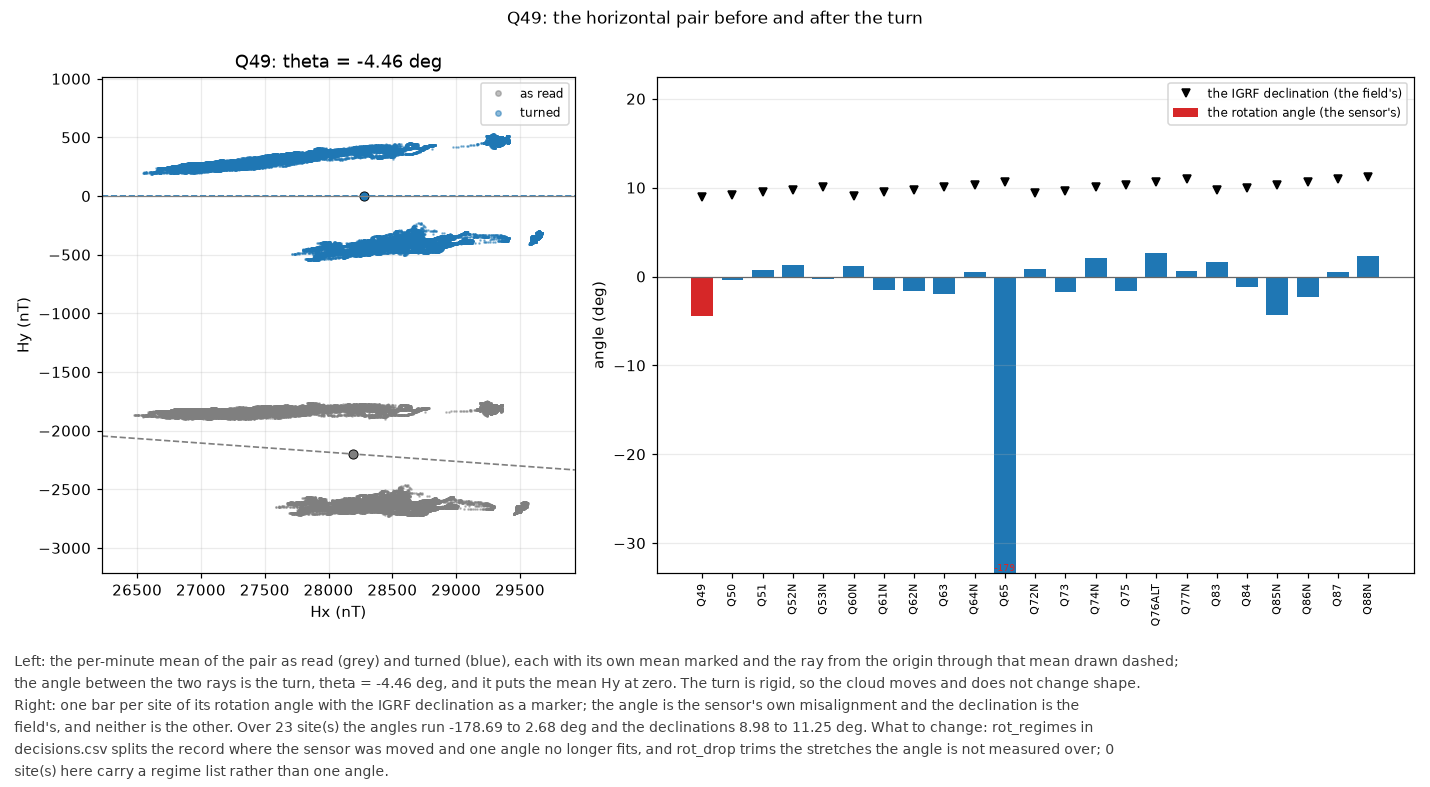

In [7]:
z = np.load(WORK / "cache_1hz" / ("%s.npz" % SHOW), allow_pickle=False)
h0 = {c: np.asarray(z[c], float) for c in ("Hx", "Hy")}
z.close()
d = sv.decision(SHOW)
h0, _a, _u = FR.apply_signs(h0, d)
h1, ang_show = FR.rotate_to_mean_field({c: h0[c].copy() for c in h0},
                                       regimes=FR.parse_regimes(d.get("rot_regimes")),
                                       drop=FR.parse_regimes(d.get("rot_drop")), fs=1.0)
show(FIGP.frame_hodogram(h0, h1, ang_show, SHOW, fr, site_dir(SHOW) / "03_frame.png", fs=1.0))
del h0, h1


## The clean pool

A site may reference another only if its own magnetic record is fit to. The tail scan walks each rotated
record in 600 s chunks and takes the median band power of Hx, Hy, Ex and Ey over 20-200 s
(`auslamp_proc.process.transients.scan`, survey.yaml `pool`), and two tests are read off it.

The event test is fleet-normalised. A chunk is an event where the site's own power exceeds 100 times its own
median AND the rest of the fleet does not see the same thing: either fewer than 3 other sites were recording
then, or this site runs more than 10 times the median of the others. A substorm lifts every site in the
array within the same ten minutes and is signal; a power-cycle or a vehicle lifts one, and only the second is
a fault. The site's own median cannot tell them apart.

The baseline test catches the other failure: a site that never spikes because it is loud all the time. The
denominator is one median over every site with a scan, so the level is a property of the instrument and the
band rather than of whoever was deployed alongside.

The band is 20-200 s. On a 1 Hz cache the 2-20 s band sits on the anti-alias filter's roll-off and reads each
unit's own noise floor: over these 23 fluxgates the 2-20 s chunk medians span five decades, where the
20-200 s medians hold inside a factor of 10 at 22 of the 23.

    clean = event fraction <= EVENT_FRAC_MAX and baseline <= BASELINE_MAX x the survey median

**This check fails if the scan is UNJUDGED at any site, that is if no chunk was scored there.**

In [8]:
scan_rows = []
for s in ALL_SITES:                              # <- every site in sites.csv: the pool is not the chosen set
    t = time.time()
    if TR.load_series(s, WORK) is None:
        t0, arrays, meta = cache.load(s, WORK, 1)
        d = sv.decision(s)
        arrays, _a, _u = FR.apply_signs(arrays, d)
        arrays, _ang = FR.rotate_to_mean_field(arrays, regimes=FR.parse_regimes(d.get("rot_regimes")),
                                               drop=FR.parse_regimes(d.get("rot_drop")), fs=1.0)
        row = TR.scan(s, t0, arrays, WORK, fs=1.0, cfg=sv.cfg)
        del arrays
        print("%-9s scanned in %5.1f s" % (s, time.time() - t), flush=True)
    else:
        row = TR.summarise(s, *TR.load_series(s, WORK))
    scan_rows.append(row)

pool, pool_table = ST.clean_pool(force=True)
base = TR.survey_baseline(ALL_SITES, WORK)
scan_t = pd.DataFrame(scan_rows).merge(pool_table, on="site")
print()
print("the survey median baseline is %.4g nT^2/Hz at 20-200 s over %d sites with a scan"
      % (base, len(scan_t)))
print(scan_t[["site", "chunks", "days", "Hx_median", "Hy_median", "event_frac", "baseline", "clean",
              "reason"]].round(4).to_string(index=False))
print()
print("the pool (%d of %d): %s" % (len(pool), len(scan_t), " ".join(pool)))
print("excluded, with the reason:")
for r in pool_table[~pool_table.clean].itertuples():
    print("   %-9s %s" % (r.site, r.reason))

unjudged = pool_table[~pool_table.judged]
print()
if not len(pool_table):
    print("VERDICT: UNJUDGED -- no site was scanned, so the pool scored nothing")
elif len(unjudged):
    print("VERDICT: FAIL -- the scan scored no chunk at %d of %d sites (%s)"
          % (len(unjudged), len(pool_table), ", ".join(unjudged.site)))
else:
    print("VERDICT: PASS -- every one of the %d sites was scored on at least one chunk, the thinnest being "
          "%d chunks at %s; %d sites are clean at events <= %s and baseline <= %sx, and the %d excluded are "
          "each named with the limb they failed"
          % (len(pool_table), int(scan_t.chunks.min()), scan_t.site[scan_t.chunks.idxmin()],
             len(pool), EVENT_FRAC_MAX, BASELINE_MAX, len(pool_table) - len(pool)))



the survey median baseline is 0.09023 nT^2/Hz at 20-200 s over 23 sites with a scan
  site  chunks  days  Hx_median  Hy_median  event_frac  baseline  clean                                   reason
   Q49    8731 60.63   303.5968     1.9576      0.0032 3364.6167  False baseline 3364.6x > 10x the survey median
   Q50    8841 61.40     0.0487     0.0189      0.0088    0.5398   True                                         
   Q51    8787 61.02     0.1372     0.4231      0.0419    4.6895  False             event fraction 0.0419 > 0.02
  Q52N    8894 61.76     0.0928     0.0823      0.0690    1.0283  False             event fraction 0.0690 > 0.02
  Q53N    8788 61.03     0.0841     0.0428      0.0076    0.9316   True                                         
  Q60N    8758 60.82     0.0322     0.0120      0.0178    0.3565   True                                         
  Q61N    8723 60.58     0.0679     0.0659      0.0624    0.7528  False             event fraction 0.0624 > 0.02
  Q62N    8

The two limbs of the pool rule as bars. Look for how far an excluded site sits from its line: a site
just over EVENT_FRAC_MAX is a different case from one an order of magnitude over, and the baseline panel is
logarithmic because the baselines span decades. A site carrying both letters failed both limbs; a site
carrying one is inside the other.

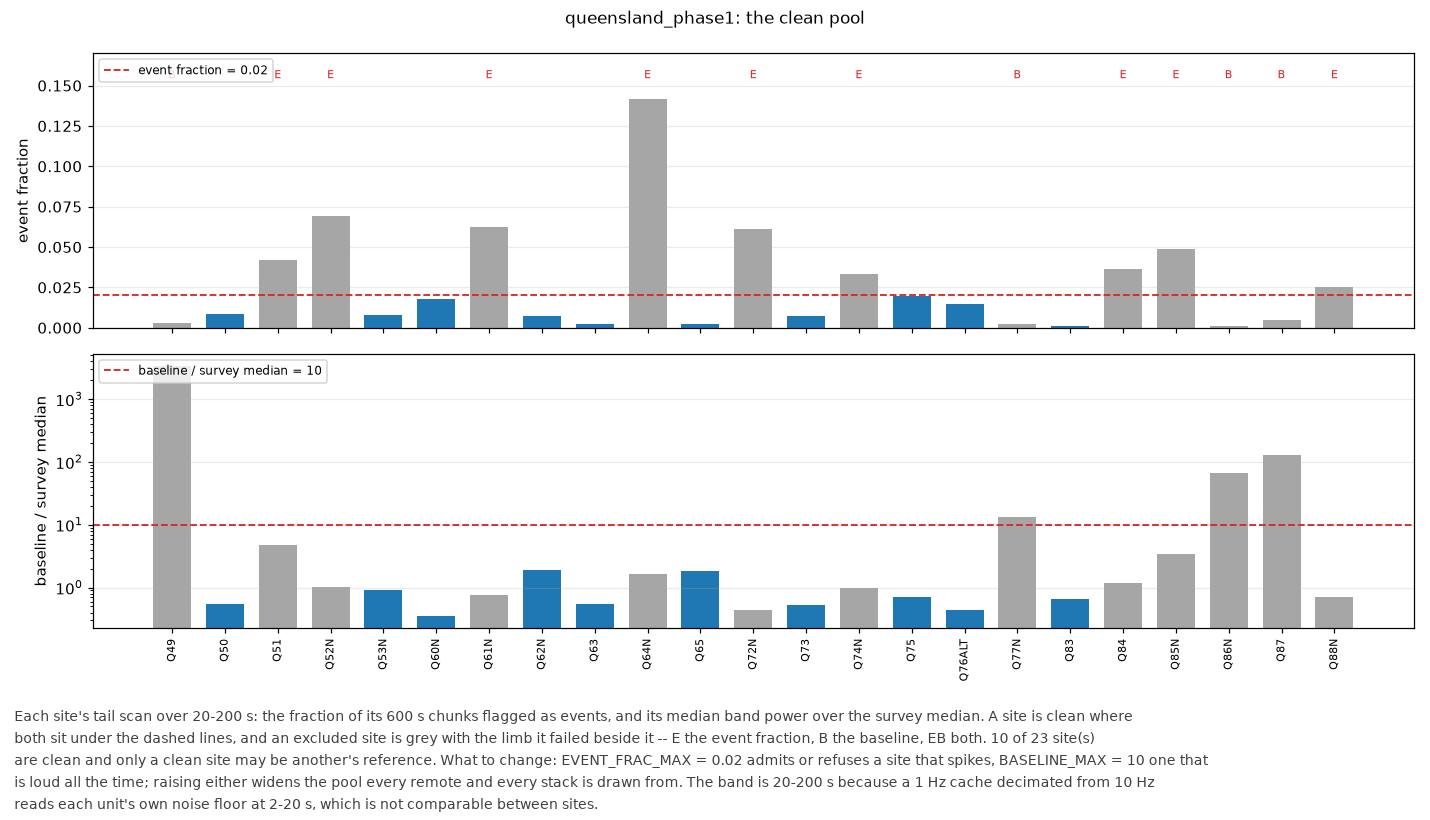

In [9]:
show(FIGP.pool_bars(scan_t, OUT / "03_pool.png", event_frac_max=EVENT_FRAC_MAX,
                    baseline_max=BASELINE_MAX, survey=sv.cfg["name"]))


## The remote site

Every candidate in the target's own overlap group is scored: the distance in km, the usable overlap in days,
its event fraction and baseline from the scan above, and the event-free 20-200 s coherence of the pair. The
coherence is a chunk median and never one pass over the whole record -- one transient inside one Welch
segment otherwise takes a whole record's score to the floor -- and nothing is concatenated: the uncut overlap
is walked in whole 1,024 s segments and a segment is used only where the mask is true right through it, so
the estimator never reads a join it made itself.

A candidate is scored only where its overlap reaches min(MIN_OVERLAP_DAYS, 0.75 x the days the target can
use). The days the target can use, not the length of its cache: a cache is as long as the logger ran, not as
long as the magnetics are sound.

The choice is then the five-branch rule, and the branch is recorded in the product:

1. clean, coh >= COH_MIN, overlap >= 90 per cent -- the nearest of them
2. clean, coh >= COH_MIN -- the longest overlap
3. clean, coh >= COH_RELAX -- the most coherent
4. coh >= COH_MIN but not clean -- the fewest events
5. none of the above -- the nearest by km

Where `decisions.csv` names a remote, that site is used and the rule's own choice is printed beside it as a
reading.

**This check fails if any chosen remote has no overlap with its target or is not in the target's overlap
group.**

In [10]:
groups = ST.groups()
remote_rows, cand_tables = [], {}
for s in CHOSEN:
    scores = ST.score_candidates(s)
    cand_tables[s] = scores
    ch = ST.remote_site(s, scores=scores)
    ov = ST.overlap(s, ch["name"]) if ch.get("name") else None
    coh = ch.get("coh")
    if coh is None and ch.get("name") and ov is not None:
        # a remote decisions.csv names from outside the clean pool is not in the candidate table, so it
        # carries no score there; it is measured here on the same rule so the column is never empty
        coh = round(float(ST.pair_coherence(s, ch["name"])["coh"]), 3)
    remote_rows.append(dict(site=s, campaign_remote=str(sv.decision(s).get("remote_site", "")),
                            rule_remote=ch.get("rule_name"), rule_branch=ch.get("rule_branch"),
                            rule_coh=ch.get("rule_coh"), chosen=ch.get("name"),
                            source=ch.get("source"), coh=coh,
                            overlap_days=(round((ov[1] - ov[0]) / 86400.0, 2) if ov else 0.0),
                            group=groups.get(s, ""), remote_group=groups.get(ch.get("name"), ""),
                            n_candidates=len(ch.get("candidates", [])), reason=ch.get("reason", "")[:150]))
rem = pd.DataFrame(remote_rows)
print("the candidates of %s, the first of the chosen set" % CHOSEN[0])
print(cand_tables[CHOSEN[0]].round(4).to_string(index=False))
print()
print(rem[["site", "campaign_remote", "rule_remote", "rule_branch", "rule_coh", "chosen", "source",
           "coh", "overlap_days", "group", "remote_group"]].to_string(index=False))
print()
differ = rem[(rem.campaign_remote.str.lower() != "decide") & (rem.campaign_remote != rem.rule_remote)]
print("the campaign's remote and the rule's choice differ at %d of %d sites (a reading, not a criterion):"
      % (len(differ), len(rem)))
for r in differ.itertuples():
    print("   %-9s campaign %-8s rule %-8s (branch %s, coh %s)"
          % (r.site, r.campaign_remote, r.rule_remote, r.rule_branch, r.rule_coh))
print()
print("the branch the rule took, over the chosen set")
print(rem.rule_branch.value_counts().sort_index().to_string())
print()
for r in rem.itertuples():
    print("   %-9s %s" % (r.site, r.reason))

no_ov = rem[rem.overlap_days <= 0]
wrong_group = rem[(rem.group != "") & (rem.group != rem.remote_group)]
print()
if not len(rem):
    print("VERDICT: UNJUDGED -- no site was offered a remote")
elif len(no_ov) or len(wrong_group) or rem.chosen.isna().any():
    print("VERDICT: FAIL -- %d of %d chosen remotes do not overlap their target (%s); %d sit outside the "
          "target's overlap group (%s); %d sites were offered no remote at all (%s)"
          % (len(no_ov), len(rem), ", ".join(no_ov.site) or "none",
             len(wrong_group), "; ".join("%s -> %s (%s vs %s)" % (r.site, r.chosen, r.group, r.remote_group)
                                         for r in wrong_group.itertuples()) or "none",
             int(rem.chosen.isna().sum()), ", ".join(rem.site[rem.chosen.isna()]) or "none"))
else:
    print("VERDICT: PASS -- all %d chosen remotes overlap their target, the shortest by %.2f d at %s, and "
          "every one sits in the target's own overlap group; %d came from decisions.csv and %d from the rule"
          % (len(rem), rem.overlap_days.min(), rem.site[rem.overlap_days.idxmin()],
             int((rem.source == "decisions.csv").sum()), int((rem.source != "decisions.csv").sum())))


the candidates of Q49, the first of the chosen set
  name    km  overlap_days  overlap_frac  event_frac  baseline  clean   coh  chunks   ok why  own_days  min_overlap_days  chunk_days  clean_days  mask_frac
   Q50  79.1          60.5         0.998      0.0088       0.5   True 0.026     121 True          60.6              20.0         0.5        60.5     0.0122
  Q53N 373.1          58.6         0.967      0.0076       0.9   True 0.025     117 True          60.6              20.0         0.5        58.5     0.0108
  Q60N 100.6          59.9         0.989      0.0178       0.4   True 0.027     120 True          60.6              20.0         0.5        60.0     0.0211
  Q62N 188.7          59.7         0.984      0.0071       1.9   True 0.022     120 True          60.6              20.0         0.5        60.0     0.0105
   Q63 300.6          58.5         0.965      0.0023       0.5   True 0.025     117 True          60.6              20.0         0.5        58.5     0.0056
   Q65 483.8 

The candidates of one site as a scatter, and the branch taken over the whole set. Look at where the
candidates sit relative to the two coherence lines and the overlap line: a site whose candidates all sit below
COH_MIN took branch 3 or 5 and its remote is the best of a weak field, not a good reference. A site with
several candidates above COH_MIN and to the right of the overlap line had a real choice, and the rule took the
nearest of them.

The branch histogram says the same thing about the survey: branch 1 everywhere means the array was dense
enough that the rule never had to relax anything.

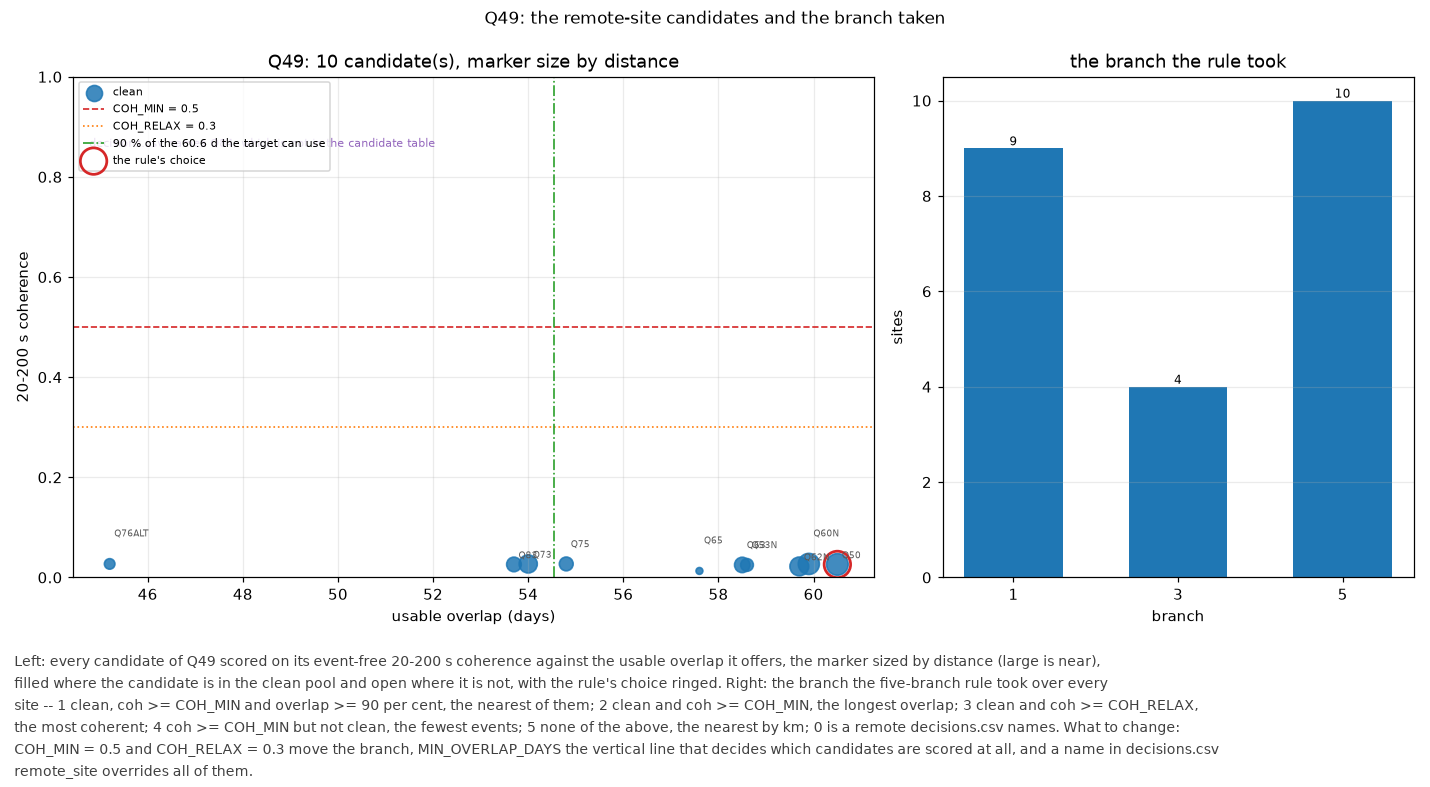

In [11]:
branch_counts = rem.rule_branch.value_counts().sort_index().to_dict()
named_show = str(sv.decision(SHOW).get("remote_site", "")).strip()
named_show = named_show if named_show.lower() not in ("decide", "", "nan", "none") else None
show(FIGP.remote_scatter(cand_tables[SHOW], ST.remote_site(SHOW, scores=cand_tables[SHOW]), SHOW,
                         site_dir(SHOW) / "03_remote.png", branches=branch_counts, coh_min=COH_MIN,
                         coh_relax=COH_RELAX, named=named_show))


## The fleet stack

A member's weight is its median coherence with the fleet at 100-1000 s, and never its coherence with the
target: whether a reference is a good measurement of the regional field is a question about the reference
and the field, and weighting a member by its agreement with the target puts the target's own noise into its
reference. The fleet table below is one median per member over its pairs with the rest of the pool, and it
is the same table for every target.

Members below STACK_CUTOFF are refused, the best STACK_MAX are kept, and a stack with fewer than STACK_MIN
members is refused outright: a one-member stack is a remote site renamed.

Each member is aligned first. The lag is the median 5-20 s cross-correlation over up to eight event-free
two-day windows spread across the record, and it is accepted only where it is one constant, spread at most
1.0 s: no single shift fixes a free-running clock. A member whose lag cannot be measured or is not one
constant is kept at lag 0 with the reason recorded, because these are GPS-disciplined loggers.

A member passes four steps between its cache and the sum, in this order. Its own transient chunks are NaN.
Then `references.EDGE_S` = 120 s inside every record end and every gap end is NaN, at every rate: the
samples either side of a break carry the logger's settling, thousands of nT at a PR6-24, and over the two
Queensland phases a member's first minute runs at 37 times the record's own rate of steps above 2 nT and the
last minute of a run at 3.5 times. Then the lag is applied as a Lanczos-windowed sinc of `align.LANCZOS_A`
= 16 taps either side, which is local: one impulsive sample stays where it is, a NaN reaches only 32
samples, and the error against an analytic sine shifted 0.37 s is 0.3 per cent of the amplitude at 2.3 s,
the shortest period the 1 Hz band file estimates.

Then `references.member_screen` compares the members with each other. Where three or more are finite, a
sample whose first difference departs from the median over them by more than max(`SCREEN_K` = 30 x MAD,
`SCREEN_FLOOR_NT` = 3.0 nT) is flagged; a spike the whole fleet sees is the field, is carried by the median,
and is not flagged. Where exactly two are finite the median of two first differences does not name the
culprit, so a sample is flagged where one member's own first difference passes that bar and the other's is
under 1.5 nT, and where both pass it neither is flagged. The flagged span, from two samples before to three
after and merged with its neighbours, is bridged by a straight line inside that member where the span is at
most 12 s. The line and not a hole: a member that goes NaN drops out of the weighted mean over that span.

Then `references.level_match` sets each member on the fleet's own level: its offset from the median of the
members finite at each sample is taken in two robust steps -- the median of each `LEVEL_BLOCK_S` = 60 s
block, then the running median of 60 of those blocks, `LEVEL_WIN_S` = 3600 s -- interpolated back to the
sample grid and subtracted, so a member entering or leaving the sum does not step the level. Medians and not
a mean, because a mean is dragged by whatever excursion sits at a run edge. The match changes the stack's
content only at periods above about 3600 s, and only by the difference between the weighted mean and the
median of the coherent members. Each member's offset rms is written to the sidecar.

A sample where a member is NaN does not add to that member's weight there, so the mean is over whoever is
sound and the weights renormalise per sample. A sample carried by fewer than `STACK_MIN` members is zero and
its mask False, on the same rule the member list is judged on: one member is a member renamed, per sample as
per list, and the count of samples so masked is in the sidecar. Where no member is sound the stack is zero
and its mask is False as well: a zero reference contributes nothing to either the cross- or the
auto-spectrum, so those windows drop out of the estimate instead of biasing it.

**This check fails if any stack carries a member weighted by its coherence with the TARGET rather than the
fleet, or a member outside the pool.** The first limb is scored by recomputing one site's weights from the
fleet coherence table printed above and comparing them with the weights in that site's own sidecar, and by
comparing the same weights against the target coherences of the candidate table: a weight that matches the
target column and not the fleet column is the wrong rule.

In [12]:
weights, pairs = ST.fleet_weights()
fleet = pd.DataFrame([dict(member=k, fleet_coh_100_1000s=v,
                           pairs=sum(1 for p in pairs if k in p.split(":")))
                      for k, v in sorted(weights.items())])
print("the fleet coherence of every pool member at 100-1000 s, the median over its pairs with the rest")
print(fleet.to_string(index=False))
print()
print("the pairs it is the median of")
pf = pd.DataFrame([dict(pair=k, coh=v["coh"], chunks=v["chunks"]) for k, v in sorted(pairs.items())])
print(pf.to_string(index=False))

stack_rows, member_rows, stacks = [], [], {}
for s in CHOSEN:
    kept, lags, refused, notes = ST.stack_members(s)
    stacks[s] = (kept, lags, refused, notes)
    stack_rows.append(dict(site=s, n_members=len(kept),
                           members=" ".join(kept), weights=" ".join("%.3f" % v for v in kept.values()),
                           lags_s=" ".join("%+.2f" % lags.get(d, 0.0) for d in kept),
                           refused=len(refused), notes=len(notes)))
    for d, w in kept.items():
        member_rows.append(dict(site=s, member=d, weight=w, lag_s=lags.get(d, 0.0),
                                note=notes.get(d, ""), in_pool=d in pool))
    for d, why in sorted(refused.items()):
        member_rows.append(dict(site=s, member=d, weight=None, lag_s=None, note=why, in_pool=d in pool))
sk = pd.DataFrame(stack_rows)
mem = pd.DataFrame(member_rows)
print()
print(sk.to_string(index=False))
print()
print("every member and every refusal, per site")
print(mem.to_string(index=False))
print()
refused_sites = sk[sk.n_members < STACK_MIN]
print("stacks refused for want of members: %s"
      % (", ".join("%s (%d < %d)" % (r.site, r.n_members, STACK_MIN)
                   for r in refused_sites.itertuples()) or "none"))

# limb A, recomputed: the weight of every member has to be the fleet value and not the target value
probe = CHOSEN[0]
kept = stacks[probe][0]
cand = cand_tables[probe].set_index("name")
recomputed = {d: weights.get(d) for d in kept}
target_coh = {d: (float(cand.loc[d, "coh"]) if d in cand.index and cand.loc[d, "coh"] is not None
                  else None) for d in kept}
print()
print("%s: the weight in the store against the fleet table and against this site's own target coherence"
      % probe)
print(pd.DataFrame([dict(member=d, in_store=kept[d], fleet_table=recomputed[d], target_coh=target_coh[d])
                    for d in kept]).to_string(index=False))
wrong_rule = [d for d in kept if recomputed[d] is None or abs(kept[d] - recomputed[d]) > 1e-6]
looks_like_target = [d for d in kept if target_coh[d] is not None and abs(kept[d] - target_coh[d]) < 1e-6
                     and (recomputed[d] is None or abs(target_coh[d] - recomputed[d]) > 1e-6)]
outside = sorted(set(mem.member[(mem.weight.notna()) & (~mem.in_pool)]))
scored = int(mem.weight.notna().sum())
print()
if not scored:
    print("VERDICT: UNJUDGED -- no stack carries a member, so no weight was scored")
elif wrong_rule or looks_like_target or outside:
    print("VERDICT: FAIL -- %d of %s's %d members do not carry the fleet weight (%s); %d carry the target "
          "coherence instead (%s); %d members over all %d stacks sit outside the clean pool (%s)"
          % (len(wrong_rule), probe, len(kept), ", ".join(wrong_rule) or "none",
             len(looks_like_target), ", ".join(looks_like_target) or "none",
             len(outside), len(sk), ", ".join(outside) or "none"))
else:
    print("VERDICT: PASS -- all %d of %s's members carry the fleet coherence recomputed from the table "
          "above to within 1e-6 and none carries its target coherence (which differs by %.3f to %.3f), and "
          "every one of the %d members over %d stacks is in the %d-site clean pool"
          % (len(kept), probe, min(abs(kept[d] - target_coh[d]) for d in kept if target_coh[d] is not None),
             max(abs(kept[d] - target_coh[d]) for d in kept if target_coh[d] is not None),
             scored, len(sk), len(pool)))


the fleet coherence of every pool member at 100-1000 s, the median over its pairs with the rest
member  fleet_coh_100_1000s  pairs
   Q50               0.9647      9
  Q53N               0.9330      9
  Q60N               0.9610      9
  Q62N               0.9342      9
   Q63               0.9569      9
   Q65               0.1490      9
   Q73               0.9659      9
   Q75               0.9577      9
Q76ALT               0.9609      9
   Q83               0.9598      9

the pairs it is the median of
       pair    coh  chunks
   Q50:Q53N 0.9330     119
   Q50:Q60N 0.9822     119
   Q50:Q62N 0.9444     119
    Q50:Q63 0.9629     117
    Q50:Q65 0.1502     115
    Q50:Q73 0.9814     108
    Q50:Q75 0.9647     108
 Q50:Q76ALT 0.9671      90
    Q50:Q83 0.9757     107
  Q53N:Q60N 0.9352     116
  Q53N:Q62N 0.8937     115
   Q53N:Q63 0.9499     113
   Q53N:Q65 0.1512     111
   Q53N:Q73 0.9349     104
   Q53N:Q75 0.9323     104
Q53N:Q76ALT 0.9349      86
   Q53N:Q83 0.9100     103
  


  site  n_members                               members                                         weights                                          lags_s  refused  notes
   Q49          8  Q73 Q50 Q60N Q76ALT Q83 Q75 Q63 Q62N 0.966 0.965 0.961 0.961 0.960 0.958 0.957 0.934 +0.00 +0.04 -0.06 +0.10 +0.00 -0.12 +0.12 +0.00        2      3
   Q50          8 Q73 Q60N Q76ALT Q83 Q75 Q63 Q62N Q53N 0.966 0.961 0.961 0.960 0.958 0.957 0.934 0.933 -0.10 -0.24 -0.04 +0.00 -0.00 -0.05 -0.27 -0.17        1      1
   Q51          8  Q73 Q50 Q60N Q76ALT Q83 Q75 Q63 Q62N 0.966 0.965 0.961 0.961 0.960 0.958 0.957 0.934 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00        2      8
  Q52N          8  Q73 Q50 Q60N Q76ALT Q83 Q75 Q63 Q62N 0.966 0.965 0.961 0.961 0.960 0.958 0.957 0.934 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00 +0.00        2      8
  Q53N          8  Q73 Q50 Q60N Q76ALT Q83 Q75 Q63 Q62N 0.966 0.965 0.961 0.961 0.960 0.958 0.957 0.934 +0.00 +0.17 -0.35 +0.00 +0.00 +0.27 +0.00 +0.00        

The weights and what they produce. On the left, look at how far the kept members stand above
STACK_CUTOFF: a stack whose members all sit just over the line is a stack of marginal references, and raising
the cutoff would refuse it outright. The lag written on each bar is what the alignment measured; on
GPS-disciplined loggers these are fractions of a second and a member whose lag could not be measured is kept
at zero with the reason in the table above.

On the right, the stack is drawn over the target and two of its members through six hours of one quiet day,
every trace demeaned, with a mark under the traces wherever the spike screen bridged a member sample. The
stack follows the same field as the target; how much rougher or smoother it is than its members is a number
and not a matter for the eye, and the check below scores it.

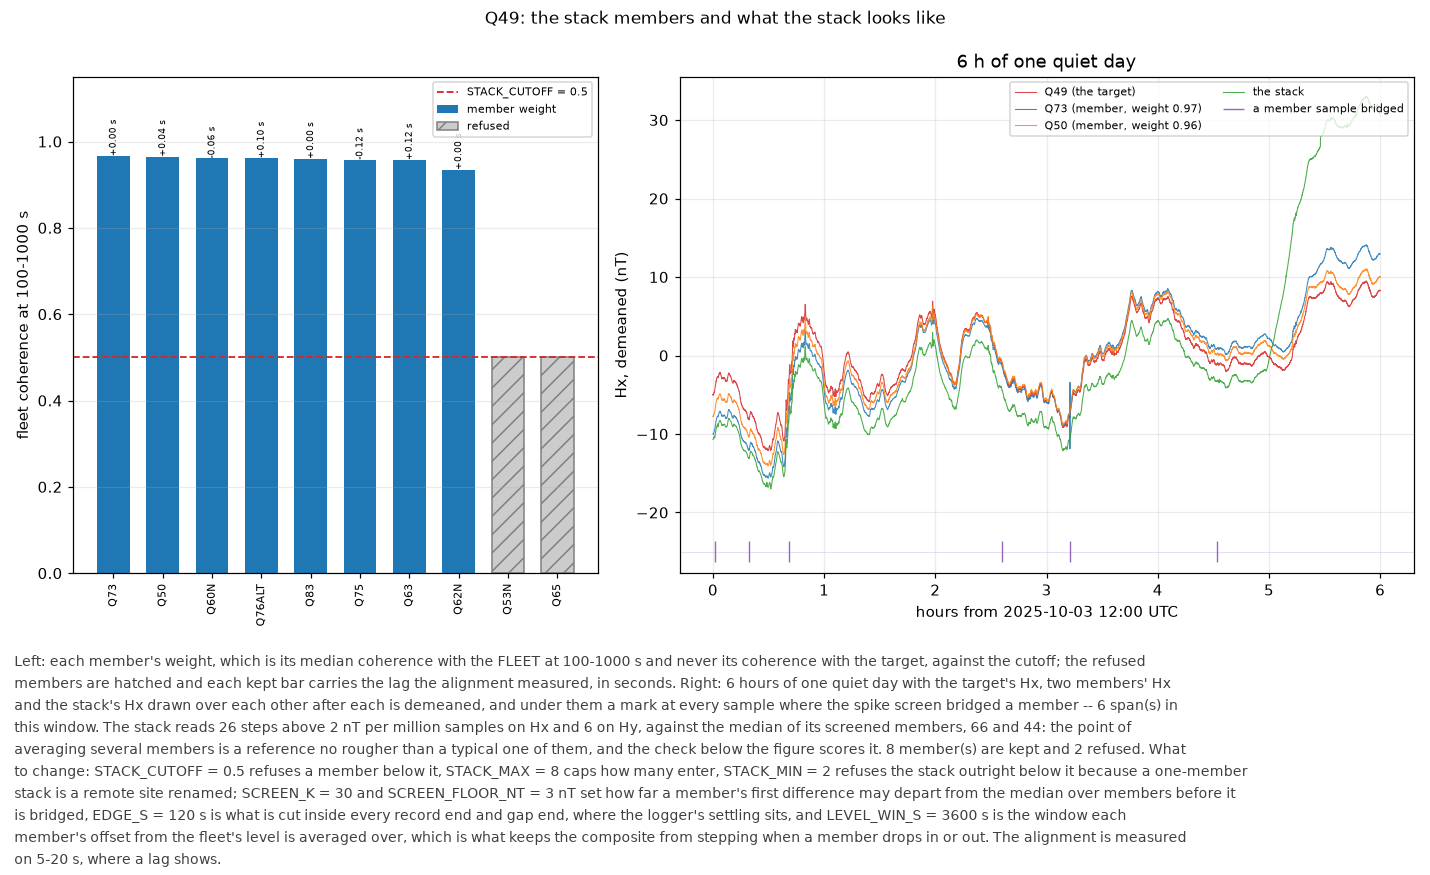

In [13]:
t0s, n_s = ST.window(SHOW)
_t, h_show, _ang, _n = ST.rotated(SHOW)
kept_show = stacks[SHOW][0]
lags_show = stacks[SHOW][1]
members_drawn = list(kept_show)[:2]
try:
    _rt, rh_stack, _rm, stack_info = REF.load_reference("stack", SHOW, RATES1[0], WORK)
except FileNotFoundError:
    rh_stack, stack_info = None, {}
grids = [np.asarray(h_show["Hx"], float)]
labels = ["%s (the target)" % SHOW]
colours = ["C3"]
for m in members_drawn:
    grids.append(np.asarray(ST._on_grid(m, t0s, n_s, drop_events=True,
                                        lag_s=lags_show.get(m))["Hx"], float))
    labels.append("%s (member, weight %.2f)" % (m, kept_show[m]))
    colours.append("C0" if len(colours) == 1 else "C1")
if rh_stack is not None:
    grids.append(np.asarray(rh_stack["Hx"], float))
    labels.append("the stack")
    colours.append("C2")
i0 = quiet_window(grids, fs=float(RATES1[0]), hours=6.0)
w = int(6 * 3600 * RATES1[0])
series = ([] if i0 is None else [(lb, g[i0:i0 + w], c) for lb, g, c in zip(labels, grids, colours)])
# the marks under the traces are the spans the spike screen bridged, read from the store's own npz and cut
# to the drawn window; Hx is the channel drawn, so Hx is the channel marked
scr_show = stack_info.get("screen") or {}
bridged = ([] if i0 is None else
           [(max(int(a) - i0, 0), min(int(b) - i0, w))
            for a, b in REF.bridged_spans("stack", SHOW, RATES1[0], WORK, "Hx")
            if int(b) > i0 and int(a) < i0 + w])
show(FIGP.stack_weights(kept_show, stacks[SHOW][2], lags_show, SHOW,
                        site_dir(SHOW) / "03_stack.png", series=series,
                        t_start=(None if i0 is None else t0s + i0 / RATES1[0]),
                        cutoff=STACK_CUTOFF, n_max=STACK_MAX, n_min=STACK_MIN, fs=float(RATES1[0]),
                        bridged=bridged, steps=(scr_show.get("steps_per_million") or {}),
                        screen_k=REF.SCREEN_K, screen_floor_nt=REF.SCREEN_FLOOR_NT, edge_s=REF.EDGE_S,
                        step_nt=REF.STEP_NT, level_win_s=REF.LEVEL_WIN_S))
del grids, rh_stack


**This check fails if any stack channel's rate of steps > 2 nT per million samples exceeds the
median rate of its screened members.** A step of more than `references.STEP_NT` = 2.0 nT from one sample to
the next is not the field on a quiet day at these periods: it is a logger spike or a settling sample at the
edge of a record. The rate is counted over each channel's finite samples in order, the same way on a member
and on the stack built from it, so a screen that leaves holes is charged for them.

The yardstick is the members as they enter the sum, screened and set on the fleet's level, and not as they
came off the logger. A stack is a combination of what goes into it and has to be at least as clean as its
median input; the raw member rate moves with whatever the neighbours' own noise happens to be and measures
the wrong thing. Both medians are in the sidecar, raw and screened, beside the stack's own rate, and this
cell reads them and recomputes nothing.

Both stack kinds are scored on the same yardstick. The stack + observatory is a combination of the same site
members with one more, and the observatory is set on the members' established level one-sidedly -- it never
enters the median it is matched against -- so its composite answers to the site members' median as the fleet
stack does.

In [14]:
# the numbers come from each sidecar; nothing here recomputes a reference
step_rows = []
for s in CHOSEN:
    for kind in ("stack", "stack_obs"):
        p = ST.path(kind, s).with_suffix(".json")
        if not p.exists():
            continue
        scr = json.loads(p.read_text(encoding="utf-8")).get("screen") or {}
        sp = scr.get("steps_per_million") or {}
        mem = scr.get("members") or {}
        obs = scr.get("observatory") or {}
        for c in ("Hx", "Hy"):
            a = (sp.get("stack") or {}).get(c)
            b = (sp.get("members_median_screened") or {}).get(c)
            if a is None or b is None:
                continue
            per = [v.get(c) or {} for v in mem.values()]
            off = [float(v.get("offset_rms_nt") or 0.0) for v in per]
            off += [float((v.get(c) or {}).get("offset_rms_nt") or 0.0) for v in obs.values()]
            step_rows.append(dict(site=s, kind=kind, channel=c, stack_steps=float(a),
                                  members_screened=float(b),
                                  members_raw=(sp.get("members_median_raw") or {}).get(c),
                                  margin=round(float(b) - float(a), 1),
                                  flagged=sum(int(v.get("flagged") or 0) for v in per),
                                  bridged=sum(int(v.get("bridged") or 0) for v in per),
                                  nan_spans=sum(int(v.get("nan_spans") or 0) for v in per),
                                  offset_rms_nt=round(max(off or [0.0]), 2),
                                  on_floor=sum(1 for v in per
                                               if "floor" in str(v.get("threshold_from")))))
sp_tab = pd.DataFrame(step_rows)
if len(sp_tab):
    print("steps above %g nT per million samples: each stack kind against the median of its screened site "
          "members, with the raw median beside it and what the screen and the level match did" % REF.STEP_NT)
    print(sp_tab.to_string(index=False))
    print()
    print("on_floor counts the members whose threshold was set by SCREEN_FLOOR_NT = %g nT rather than by "
          "SCREEN_K = %g x MAD; offset_rms_nt is the largest offset the level match removed, the "
          "observatory's included where the kind carries one" % (REF.SCREEN_FLOOR_NT, REF.SCREEN_K))
print()
rough = sp_tab[sp_tab.stack_steps > sp_tab.members_screened] if len(sp_tab) else sp_tab
if not len(sp_tab):
    print("VERDICT: UNJUDGED -- no stack sidecar carries the statistic, so nothing was scored; the store "
          "section below writes the sidecars and this cell reads them on a re-run")
elif len(rough):
    worst = rough.loc[rough.margin.idxmin()]
    print("VERDICT: FAIL -- %d of %d stack-channel(s) are rougher than the median of their own screened "
          "members. The worst is %s %s %s at %.0f steps above %g nT per million samples against a screened "
          "members' median of %.0f; the others are %s"
          % (len(rough), len(sp_tab), worst.site, worst.kind, worst.channel, worst.stack_steps,
             REF.STEP_NT, worst.members_screened,
             ", ".join("%s %s %s (%.0f vs %.0f)" % (r.site, r.kind, r.channel, r.stack_steps,
                                                    r.members_screened)
                       for r in rough.drop(index=worst.name).itertuples()) or "none"))
else:
    worst = sp_tab.loc[sp_tab.margin.idxmin()]
    print("VERDICT: PASS -- all %d stack-channel(s) over %d site(s) and %d kind(s) are at least as smooth "
          "as the median of their own screened members. The narrowest margin is %s %s %s at %.0f steps "
          "above %g nT per million samples against a screened members' median of %.0f, and over the whole "
          "set the screen flagged %d sample(s), bridged %d span(s) and left %d NaN"
          % (len(sp_tab), sp_tab.site.nunique(), sp_tab.kind.nunique(), worst.site, worst.kind,
             worst.channel, worst.stack_steps, REF.STEP_NT, worst.members_screened,
             int(sp_tab.flagged.sum()), int(sp_tab.bridged.sum()), int(sp_tab.nan_spans.sum())))


steps above 2 nT per million samples: each stack kind against the median of its screened site members, with the raw median beside it and what the screen and the level match did
  site      kind channel  stack_steps  members_screened  members_raw  margin  flagged  bridged  nan_spans  offset_rms_nt  on_floor
   Q49     stack      Hx         26.1              65.7        428.4    39.6    22930     8748        267        1369.22         8
   Q49     stack      Hy          6.2              43.5        355.1    37.3    25857     9388        361         162.96         8
   Q49 stack_obs      Hx         22.0              65.7        428.4    43.7    22930     8748        267       31539.11         8
   Q49 stack_obs      Hy          5.2              43.5        355.1    38.3    25857     9388        361         162.96         8
   Q50     stack      Hx         43.5              87.6        482.5    44.1    42181    16179        550        1186.26         8
   Q50     stack      Hy          6.8

## The observatory

The INTERMAGNET one-second record of the survey's own observatory, read out of the archive over each site's
window and turned into the mean-field frame of that window like any other member. It is never shifted: a
delay on a single reference cancels exactly in Z, so shifting it would change nothing and leaving it alone
keeps that invariance available as a check.

Its weight in the stack + observatory is measured on the same rule as a site member's -- the median
coherence with the pool at 100-1000 s -- so it enters at a weight on the members' own scale rather than at
its agreement with any one target.

The coherence of each site with the observatory is a reading. It says how much of the site's long-period
field the observatory shares from several hundred kilometres away, which is what the observatory kind can
buy and what it cannot: at the short end a distant observatory shares almost nothing.

In [15]:
w_obs, obs_pairs = ST.observatory_weight(OBS)
print("observatory %s, %s" % (OBS, geo.OBSERVATORIES.get(OBS, ("", 0, 0))[0]))
print("its fleet weight at 100-1000 s is %s, the median over %d pool members"
      % (w_obs, sum(1 for v in obs_pairs.values() if v is not None)))
print()
obs_rows = []
for s in CHOSEN:
    p = ST.path("obs", s).with_suffix(".json")
    km = geo.distance_km(ST.position(s), OBS)
    # a site outside the pool has no pair in the weight table; it is measured here so the reading covers
    # every site this run processes
    c = obs_pairs.get(s)
    chunks = None
    if c is None:
        r = ST.site_observatory_coh(s, OBS)
        c = None if not np.isfinite(r["coh"]) else round(float(r["coh"]), 4)
        chunks = r["chunks"]
    obs_rows.append(dict(site=s, km=round(km, 1), coh_100_1000s=c, in_pool=s in pool,
                         chunks=chunks, built=p.exists()))
ob = pd.DataFrame(obs_rows)
print(ob.to_string(index=False))
print()
print("stack + observatory: the stack's members with %s added at weight %s and lag 0" % (OBS, w_obs))
print(pd.DataFrame([dict(site=s, members=" ".join(list(stacks[s][0]) + ([OBS] if w_obs else [])),
                         n=len(stacks[s][0]) + (1 if w_obs else 0)) for s in CHOSEN]).to_string(index=False))


observatory CTA, Charters Towers, Australia
its fleet weight at 100-1000 s is 0.8698, the median over 10 pool members



  site     km  coh_100_1000s  in_pool  chunks  built
   Q49  592.8         0.1589    False    61.0   True
   Q50  615.6         0.8955     True     NaN   True
   Q51  669.6         0.7111    False    61.0   True
  Q52N  736.5         0.7286    False    62.0   True
  Q53N  802.0         0.8666     True     NaN   True
  Q60N  669.0         0.8920     True     NaN   True
  Q61N  722.5         0.8161    False    59.0   True
  Q62N  750.2         0.8486     True     NaN   True
   Q63  820.2         0.8850     True     NaN   True
  Q64N  880.9         0.7666    False    52.0   True
   Q65  951.8         0.0735     True     NaN   True
  Q72N  789.8         0.8207    False    60.0   True
   Q73  804.5         0.8872     True     NaN   True
  Q74N  862.0         0.7976    False    60.0   True
   Q75  907.3         0.8581     True     NaN   True
Q76ALT  956.9         0.8612     True     NaN   True
  Q77N 1034.6         0.6298    False    46.0   True
   Q83  894.9         0.8730     True     NaN 

The reading as a figure. On the left, look at whether the coherence falls with distance: over a few
hundred kilometres at 100-1000 s it barely does, which is why an observatory works at the long end at all. On
the right the two Hx records are drawn over each other through the same six hours; the large excursions are
shared and the small ones are not, and that is the division of labour the observatory kind rests on.

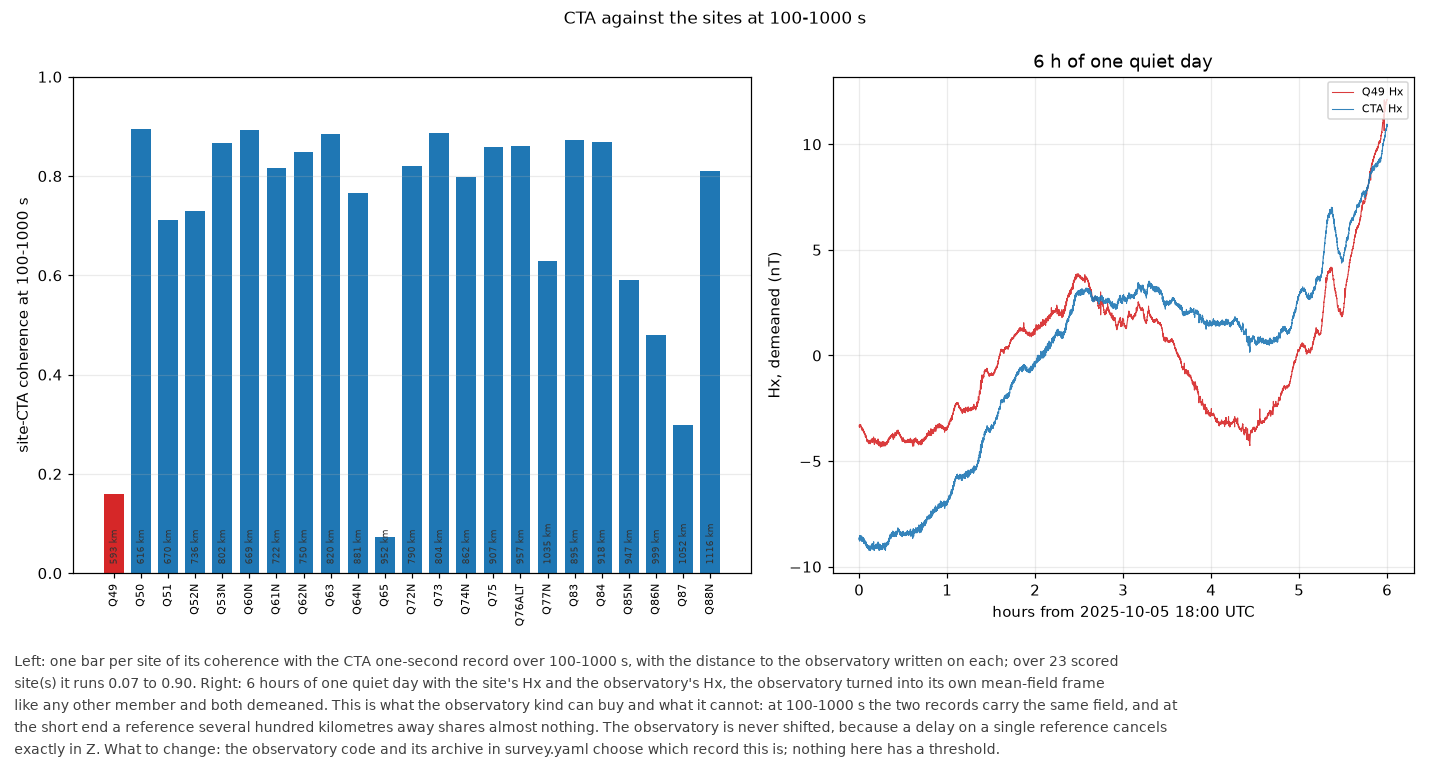

In [16]:
try:
    _ot, oh, _om, _oi = REF.load_reference("obs", SHOW, RATES1[0], WORK)
except FileNotFoundError:
    oh = None
obs_series = []
w = int(6 * 3600 * RATES1[0])
if oh is not None:
    pair = [np.asarray(h_show["Hx"], float), np.asarray(oh["Hx"], float)]
    j0 = quiet_window(pair, fs=float(RATES1[0]), hours=6.0)
    if j0 is not None:
        obs_series = [("%s Hx" % SHOW, pair[0][j0:j0 + w], "C3"),
                      ("%s Hx" % OBS, pair[1][j0:j0 + w], "C0")]
show(FIGP.observatory_bars(ob, OUT / "03_observatory.png", series=obs_series,
                           t_start=(None if not obs_series else t0s + j0 / RATES1[0]),
                           code=OBS, site=SHOW, fs=float(RATES1[0])))
del oh


## The references written to the store

Every reference is written once per rate to `<work_root>/references/<rate>hz/<kind>_<site>.npz`, with a
sidecar naming its members, their weights and lags, the refusals with their reasons, the frame and the time
it was built. A pass reads the store; it never rebuilds a reference of its own, so two products of the same
kind are built on the same array.

A 10 Hz store re-reads the 1 Hz specification -- the same pool, the same remote, the same members, weights
and lags -- on the 10 Hz grid after a spike screen. The decisions are made where they can be measured.

In [17]:
built = {}
for rate in RATES:
    st = ST if rate == RATES[0] else store(rate)
    spec = None
    if rate != 1:
        spec = store(1)                     # <- the 10 Hz store takes its decisions from the 1 Hz one
    t = time.time()
    # the observatory is not one of the 10 Hz kinds, so no observatory reference is built on that grid, and
    # a 10 Hz reference is built only for the sites the 10 Hz lane is asked for
    kinds = tuple(k for k in (KINDS if int(rate) == 1 else KINDS10) if k in REF.KINDS_WITH_STORE)
    for_sites = CHOSEN if int(rate) == 1 else ASK10
    got = REF.build_store(sv, for_sites, rate=rate, kinds=kinds, verbose=False, spec_store=spec, store=st)
    built[rate] = got
    print("%d Hz: %d sites, %d references, %.1f s" % (rate, len(got),
                                                      sum(len(v) for v in got.values()), time.time() - t))
    rows = []
    for s, d in sorted(got.items()):
        for k, info in sorted(d.items()):
            rows.append(dict(site=s, kind=k, coverage=info.get("coverage"),
                             members=" ".join(m["name"] for m in (info.get("members") or [])
                                              if m.get("role") != "refused"),
                             error=str(info.get("error", ""))[:90]))
    print(pd.DataFrame(rows).to_string(index=False))


1 Hz: 23 sites, 92 references, 0.0 s
  site      kind  coverage                                   members error
   Q49       obs    1.0000                                       CTA      
   Q49    remote    0.8728                                       Q84      
   Q49     stack    0.9885      Q73 Q50 Q60N Q76ALT Q83 Q75 Q63 Q62N      
   Q49 stack_obs    0.9885  Q73 Q50 Q60N Q76ALT Q83 Q75 Q63 Q62N CTA      
   Q50       obs    1.0000                                       CTA      
   Q50    remote    0.9512                                       Q63      
   Q50     stack    0.9740     Q73 Q60N Q76ALT Q83 Q75 Q63 Q62N Q53N      
   Q50 stack_obs    0.9740 Q73 Q60N Q76ALT Q83 Q75 Q63 Q62N Q53N CTA      
   Q51       obs    1.0000                                       CTA      
   Q51    remote    0.8508                                       Q84      
   Q51     stack    0.9658      Q73 Q50 Q60N Q76ALT Q83 Q75 Q63 Q62N      
   Q51 stack_obs    0.9658  Q73 Q50 Q60N Q76ALT Q83 Q75 Q63 Q62

10 Hz: 23 sites, 46 references, 1.2 s
  site   kind  coverage                               members error
   Q49 remote    0.8728                                   Q84      
   Q49  stack    0.9885  Q73 Q50 Q60N Q76ALT Q83 Q75 Q63 Q62N      
   Q50 remote    0.9512                                   Q63      
   Q50  stack    0.9740 Q73 Q60N Q76ALT Q83 Q75 Q63 Q62N Q53N      
   Q51 remote    0.8508                                   Q84      
   Q51  stack    0.9658  Q73 Q50 Q60N Q76ALT Q83 Q75 Q63 Q62N      
  Q52N remote    0.8386                                   Q84      
  Q52N  stack    0.9522  Q73 Q50 Q60N Q76ALT Q83 Q75 Q63 Q62N      
  Q53N remote    0.9262                                   Q63      
  Q53N  stack    0.9493  Q73 Q50 Q60N Q76ALT Q83 Q75 Q63 Q62N      
  Q60N remote    0.9767                                   Q63      
  Q60N  stack    0.9998  Q73 Q50 Q76ALT Q83 Q75 Q63 Q62N Q53N      
  Q61N remote    0.9022                                   Q83      
  Q61N  st

## The bands and the parameter set

The band file's lines are FFT harmonics of the **window**, not of the record, so a file read at another
window length names different periods and nothing says so. File, level count and window are therefore one
object in the package, `aurora_run.BANDS`, and the tables below are read through Aurora's own band machinery
rather than off the text file.

The cascade is `[1] + [4] * (levels - 1)`: the rate falls by four at each level after the first.

Under it, what the transient mask and the hour floor cost each site. Aurora gets one run per kept stretch of
at least 3,600 s; a shorter stretch holds no complete window at the deep levels and is dropped. Two events
forty minutes apart therefore cost the forty minutes between them as well as themselves, and that second
loss is measured here rather than hidden inside the mask.

1hz   bs_1hz_6lv_48.cfg      48 bands over 6 levels, window 256 samples, centres 2.303 to 48470.4 s
10hz  bs_10hz_5lv_31.cfg     31 bands over 5 levels, window 256 samples, centres 1.073 to 1211.8 s

the 1hz table, as Aurora computes it
 level    fs_hz harmonics   lower_s  centre_s   upper_s
     0 1.000000   103-120     2.124     2.303     2.498
     0 1.000000    82-102     2.498     2.801     3.141
     0 1.000000     66-81     3.141     3.504     3.908
     0 1.000000     53-65     3.908     4.366     4.876
     0 1.000000     43-52     4.876     5.420     6.024
     0 1.000000     35-42     6.024     6.686     7.420
     0 1.000000     29-34     7.420     8.164     8.982
     0 1.000000     24-28     8.982     9.892    10.894
     0 1.000000     20-23    10.894    11.959    13.128
     0 1.000000     16-19    13.128    14.725    16.516
     0 1.000000     13-15    16.516    18.392    20.480
     0 1.000000     10-12    20.480    23.492    26.947
     0 1.000000       8-9    26.947

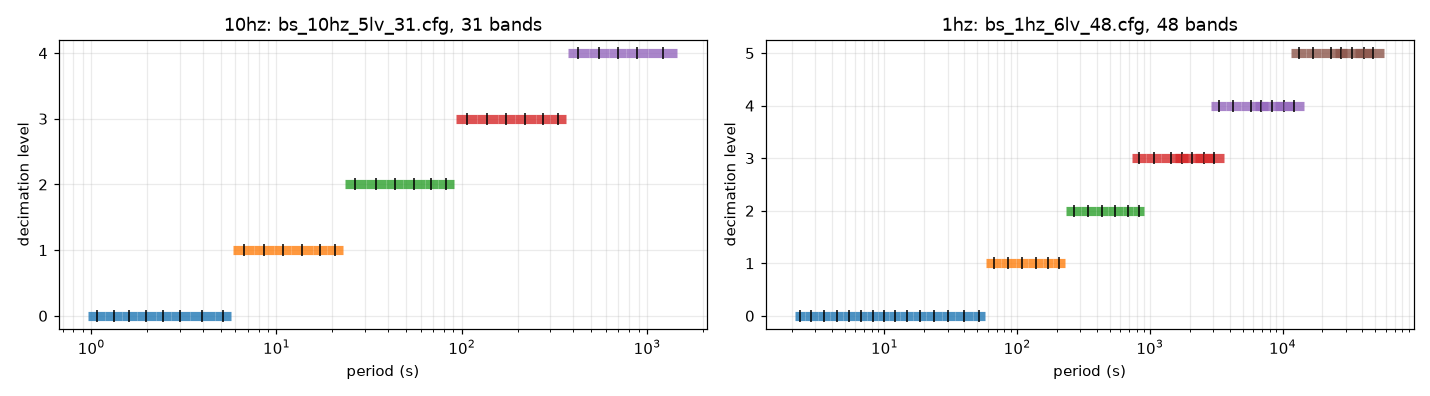


the Aurora parameter sets the package ships; kaiser20_75 is this run's
   dpss4_75       window_type=dpss, overlap=0.75, wargs={'NW': 4}
   kaiser20_50    window_type=kaiser, overlap=0.5, wargs={'beta': 20}
   kaiser20_75    window_type=kaiser, overlap=0.75, wargs={'beta': 20}
   kaiser20_w512  window_type=kaiser, overlap=0.75, wargs={'beta': 20}, window_samples=512

what the mask and the 3600 s run floor cost each site at 1 Hz


   Q49       {'site': 'Q49', 'days': 60.64, 'finite_frac': 0.99931, 'H_intervals': 15, 'E_bursts': 186, 'kept_frac': 0.94228, 'runs': 105, 'floor_loss_frac': 0.02176, 'longest_run_d': 4.3}


   Q50       {'site': 'Q50', 'days': 61.4, 'finite_frac': 1.0, 'H_intervals': 74, 'E_bursts': 138, 'kept_frac': 0.95216, 'runs': 141, 'floor_loss_frac': 0.01719, 'longest_run_d': 2.19}


   Q51       {'site': 'Q51', 'days': 61.03, 'finite_frac': 1.0, 'H_intervals': 342, 'E_bursts': 65, 'kept_frac': 0.94436, 'runs': 268, 'floor_loss_frac': 0.03731, 'longest_run_d': 2.01}


   Q52N      {'site': 'Q52N', 'days': 61.77, 'finite_frac': 1.0, 'H_intervals': 520, 'E_bursts': 211, 'kept_frac': 0.67857, 'runs': 195, 'floor_loss_frac': 0.07819, 'longest_run_d': 0.89}


...

   Q85N      {'site': 'Q85N', 'days': 60.68, 'finite_frac': 1.0, 'H_intervals': 401, 'E_bursts': 42, 'kept_frac': 0.94152, 'runs': 305, 'floor_loss_frac': 0.04211, 'longest_run_d': 1.03}


   Q86N      {'site': 'Q86N', 'days': 12.08, 'finite_frac': 1.0, 'H_intervals': 2, 'E_bursts': 7, 'kept_frac': 0.99367, 'runs': 8, 'floor_loss_frac': 0.00115, 'longest_run_d': 5.99}


   Q87       {'site': 'Q87', 'days': 60.75, 'finite_frac': 0.77384, 'H_intervals': 39, 'E_bursts': 40, 'kept_frac': 0.76161, 'runs': 64, 'floor_loss_frac': 0.00524, 'longest_run_d': 3.34}


   Q88N      {'site': 'Q88N', 'days': 60.45, 'finite_frac': 1.0, 'H_intervals': 202, 'E_bursts': 161, 'kept_frac': 0.93889, 'runs': 175, 'floor_loss_frac': 0.04101, 'longest_run_d': 2.79}



  site  days  finite_frac  H_intervals  E_bursts  kept_frac  runs  floor_loss_frac  longest_run_d
   Q49 60.64      0.99931           15       186    0.94228   105          0.02176           4.30
   Q50 61.40      1.00000           74       138    0.95216   141          0.01719           2.19
   Q51 61.03      1.00000          342        65    0.94436   268          0.03731           2.01
  Q52N 61.77      1.00000          520       211    0.67857   195          0.07819           0.89
  Q53N 61.03      1.00000           67        33    0.98464    90          0.00330           3.81
  Q60N 60.82      1.00000          150        44    0.97260   140          0.01336           3.95
  Q61N 60.58      1.00000          504       212    0.82301   307          0.09228           0.85
  Q62N 61.56      1.00000           63        62    0.97823    97          0.00587           4.45
   Q63 60.53      1.00000           20        93    0.84374    51          0.01231           4.92
  Q64N 60.94      1

In [18]:
tabs = {}
for key, bs in aurora_run.BANDS.items():
    tabs[key] = aurora_run.band_table(bs)
    print("%-5s %-22s %2d bands over %d levels, window %d samples, centres %.3f to %.1f s"
          % (key, bs.file.name, len(tabs[key]), tabs[key].level.nunique(), bs.window,
             tabs[key].centre_s.min(), tabs[key].centre_s.max()))
print()
key = "%dhz" % RATES[0]
print("the %s table, as Aurora computes it" % key)
print(tabs[key].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 3.6))
for ax, (k, tab) in zip(axes, sorted(tabs.items())):
    for r in tab.itertuples():
        ax.plot([r.lower_s, r.upper_s], [r.level, r.level], lw=6, solid_capstyle="butt",
                color="C%d" % (r.level % 10), alpha=0.8)
        ax.plot(r.centre_s, r.level, "k|", ms=8)
    ax.set(xscale="log", xlabel="period (s)", ylabel="decimation level",
           title="%s: %s, %d bands" % (k, aurora_run.BANDS[k].file.name, len(tab)),
           yticks=range(tab.level.nunique()))
    ax.grid(alpha=0.25, which="both")
fig.tight_layout()
bands_png = OUT / "03_bands.png"
fig.savefig(bands_png, dpi=110)
plt.close(fig)
WRITTEN.append(bands_png)
display(Image(filename=str(bands_png)))

print()
print("the Aurora parameter sets the package ships; %s is this run's" % PARAMS)
for name, p in sorted(aurora_run.AURORA_PARAMS.items()):
    print("   %-14s %s" % (name, ", ".join("%s=%s" % kv for kv in p.items())))
print()
print("what the mask and the %g s run floor cost each site at %g Hz" % (TR.MIN_SEGMENT_S, RATES[0]))
mask_rows = []
for s in CHOSEN:
    t0, arrays, meta = cache.load(s, WORK, RATES[0])
    d = sv.decision(s)
    arrays, _a, _u = FR.apply_signs(arrays, d)
    arrays, _ang = FR.rotate_to_mean_field(arrays, regimes=FR.parse_regimes(d.get("rot_regimes")),
                                           drop=FR.parse_regimes(d.get("rot_drop")), fs=float(RATES[0]))
    ev = TR.site_events(s, ALL_SITES, WORK, sv.cfg)
    ee = TR.e_events(s, WORK, sv.cfg)
    keep, stats = TR.build_keep(t0, {c: arrays[c] for c in mth5_build.LOCAL_CHANNELS}, float(RATES[0]),
                                ev, (), ee)
    runs = TR.segments(keep, int(TR.MIN_SEGMENT_S * RATES[0]))
    mask_rows.append(dict(site=s, days=round(stats["n"] / 86400.0 / RATES[0], 2),
                          finite_frac=stats["finite_frac"], H_intervals=len(ev), E_bursts=len(ee),
                          kept_frac=stats["kept_frac"], runs=len(runs),
                          floor_loss_frac=round(TR.floor_dropped_frac(keep, float(RATES[0])), 5),
                          longest_run_d=round(max((L for _o, L in runs), default=0) / 86400.0 / RATES[0], 2)))
    del arrays, keep
    print("   %-9s %s" % (s, mask_rows[-1]), flush=True)
mk = pd.DataFrame(mask_rows)
print()
print(mk.to_string(index=False))


The mask over the record of one site. Look at where the masked spans fall and at the row of runs
underneath: a run is green where the stretch is at least MIN_SEGMENT_S and became one Aurora run, and red
where the floor threw it away. Two events an hour apart cost the hour between them as well as themselves, and
a record carrying many short events loses far more than the sum of the events. That second loss is what the
red bars show and it is the reason to look at the figure rather than at the kept fraction alone.

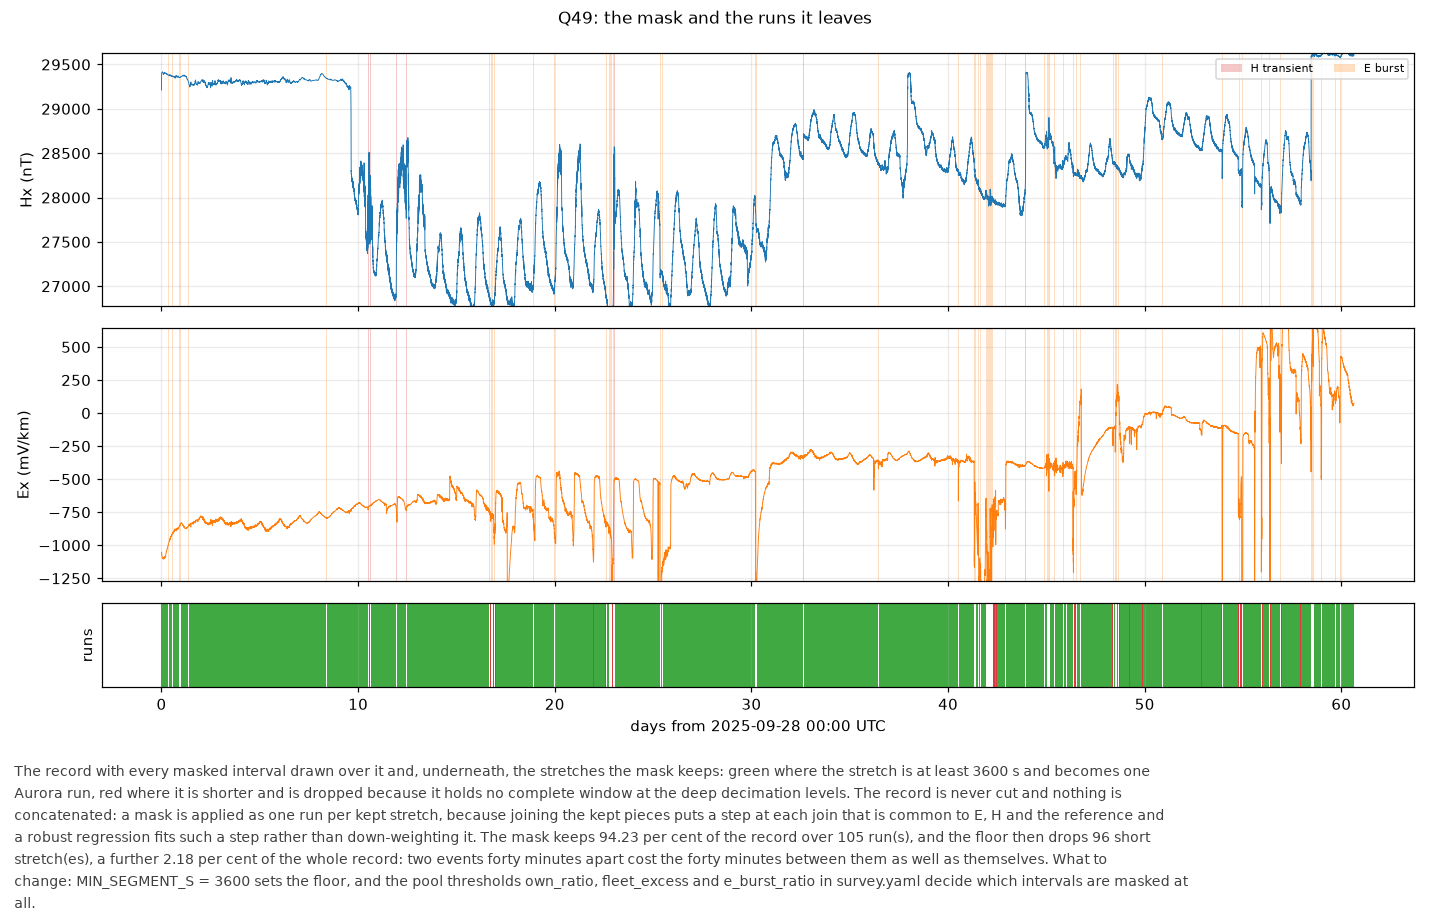

In [19]:
t0m, arrm, _meta = cache.load(SHOW, WORK, RATES1[0])
dm = sv.decision(SHOW)
arrm, _a, _u = FR.apply_signs(arrm, dm)
arrm, _ang = FR.rotate_to_mean_field(arrm, regimes=FR.parse_regimes(dm.get("rot_regimes")),
                                     drop=FR.parse_regimes(dm.get("rot_drop")), fs=float(RATES1[0]))
ev_show = TR.site_events(SHOW, ALL_SITES, WORK, sv.cfg)
ee_show = TR.e_events(SHOW, WORK, sv.cfg)
keep_show, _st = TR.build_keep(t0m, {c: arrm[c] for c in mth5_build.LOCAL_CHANNELS},
                               float(RATES1[0]), ev_show, (), ee_show)
show(FIGP.mask_record(t0m, arrm, keep_show, site_dir(SHOW) / "03_mask.png", site=SHOW,
                      spans=[("H transient", "C3", ev_show), ("E burst", "C1", ee_show)],
                      fs=float(RATES1[0]), min_segment_s=TR.MIN_SEGMENT_S))
del arrm, keep_show


## The MTH5

One site and one kind, written and read back. The MTH5 is what Aurora reads: the local station with its five
channels and, where there is a reference, a second station carrying hx and hy only on the same grid and with
the same run ids, so the kernel dataset's run-interval intersection pairs them one to one.

The channels carry nanoTesla and milliVolt per kilometer and no filter at all. The cache is already in
physical units, so a filter here would be applied a second time; the spelling of the units matters too,
because `millivolts per kilometer` resolves to `unknown per kilometer` in mt_metadata and writes the channel
with no unit.

**This check fails if the MTH5 differs from the cache sample for sample, or if its run count differs from the
kept stretches.** Every sample of every channel of every run is compared with the array it was written from.
The bound is 1e-3 nT and mV/km, which is the file's own float32 resolution at these levels.

In [20]:
probe_site = CHOSEN[0]                  # <- the first of the chosen set; any site answers the same question
probe_kind = "remote" if "remote" in KINDS else KINDS[0]
rate = RATES[0]
t0, arrays, meta = cache.load(probe_site, WORK, rate)
d = sv.decision(probe_site)
arrays, applied, undecided = FR.apply_signs(arrays, d)
arrays, ang = FR.rotate_to_mean_field(arrays, regimes=FR.parse_regimes(d.get("rot_regimes")),
                                      drop=FR.parse_regimes(d.get("rot_drop")), fs=float(rate))
local = {c: np.asarray(arrays[c], float) for c in mth5_build.LOCAL_CHANNELS}
rt0, rh, rmask, info = REF.load_reference(probe_kind, probe_site, rate, WORK)
ev = TR.site_events(probe_site, ALL_SITES, WORK, sv.cfg)
ee = TR.e_events(probe_site, WORK, sv.cfg)
ev_rem = [(pd.Timestamp(a).timestamp(), pd.Timestamp(b).timestamp())
          for a, b in (info.get("remote_events") or [])] if probe_kind == "remote" else []
keep, stats = TR.build_keep(t0, local, float(rate), ev, ev_rem, ee,
                            remote_mask=(None if rmask is None else rmask))
rid = REF.reference_station_id(probe_kind, info, OBS)
scratch = WORK / probe_site / "_mth5_check"
h5 = scratch / ("%s_%s.h5" % (probe_site, probe_kind))
t = time.time()
_p, segs = mth5_build.write_h5(h5, probe_site, local, (None if rh is None else (rid, rh)), t0, float(rate),
                               sv.cfg["name"], sv.site(probe_site), keep=keep,
                               reference_row=(sv.site(info["remote"]) if probe_kind == "remote" else None))
print("%s %s: %s written in %.1f s, %.1f MB" % (probe_site, probe_kind, h5.name, time.time() - t,
                                                h5.stat().st_size / 2 ** 20))
print("   stations  %s and %s" % (probe_site, rid or "none"))
print("   mask      keeps %.2f %% of %d samples; %d runs of at least %g s; the hour floor loses %.2f %% more"
      % (100 * stats["kept_frac"], stats["n"], len(segs), TR.MIN_SEGMENT_S,
         100 * TR.floor_dropped_frac(keep, float(rate))))
print("   runs      %s" % ", ".join("%03d %.2f d" % (i + 1, L / 86400.0 / rate)
                                    for i, (_o, L) in enumerate(segs[:12])))
back = mth5_build.read_back(h5, probe_site, local, segs, sv.cfg["name"])
print("   read back %s" % back)
n_kept_runs = len(TR.segments(keep, int(TR.MIN_SEGMENT_S * rate)))
left = mth5_build.remove(h5)          # a handle HDF5 has not released is said, not raised
if left:
    print("   %s" % left)
import shutil; shutil.rmtree(scratch, ignore_errors=True)
del arrays, local, rh

print()
if not back["samples_compared"]:
    print("VERDICT: UNJUDGED -- the MTH5 carried no sample to compare")
elif back["problems"] or back["runs_in_file"] != n_kept_runs:
    print("VERDICT: FAIL -- %d channel-runs differ from the cache (%s); the file holds %d runs where the "
          "mask leaves %d kept stretches of at least %g s"
          % (len(back["problems"]), "; ".join(back["problems"][:6]), back["runs_in_file"], n_kept_runs,
             TR.MIN_SEGMENT_S))
else:
    print("VERDICT: PASS -- %s's %s MTH5 carries all %d samples of its 5 channels over %d runs to within "
          "%.3g nT and mV/km of the rotated cache, and its run count is the %d kept stretches of at least "
          "%g s the mask leaves"
          % (probe_site, probe_kind, back["samples_compared"], back["runs_in_file"],
             back["worst_difference"], n_kept_runs, TR.MIN_SEGMENT_S))


Q49 remote: Q49_remote.h5 written in 40.0 s, 219.7 MB
   stations  Q49 and REMOTE_Q84
   mask      keeps 79.15 % of 5239020 samples; 114 runs of at least 3600 s; the hour floor loses 2.52 % more
   runs      001 0.06 d, 002 0.22 d, 003 0.16 d, 004 0.35 d, 005 0.40 d, 006 0.56 d, 007 1.65 d, 008 0.56 d, 009 0.33 d, 010 0.67 d, 011 1.88 d, 012 0.33 d


   read back {'runs_in_file': 114, 'runs_written': 114, 'samples_compared': 20073000, 'worst_difference': 0.0, 'problems': []}

VERDICT: PASS -- Q49's remote MTH5 carries all 20073000 samples of its 5 channels over 114 runs to within 0 nT and mV/km of the rotated cache, and its run count is the 114 kept stretches of at least 3600 s the mask leaves


## The run

One subprocess per site, `LANES` of them at a time, each running
`python -m auslamp_proc.process.run` over that site's kinds and rates. A lane pins its BLAS threads to three:
a lane that takes every core makes three lanes slower than one, and the memory a pass peaks at is per lane.
Over AusLAMP Queensland Phase 1, whose records run 12-62 days, a 1 Hz pass peaks at 2.5-4.8 GB and takes
140-900 s; a whole-record 10 Hz pass peaks at 22-37 GB, which is why the 10 Hz kinds run on hour selections
(a few GB each) and `LANES` is 3 at 1 Hz.

The CLI is resumable by design. With `REDO` False a product whose EDI is already on disk is left alone and
reported as `exists`, so a run stopped part way is finished by re-running this cell. A product that fails is
caught, its error goes into its own ledger row, and the next product runs.

Each product writes `<site>_<kind>_<rate>hz_<params>.edi` and `.xml` into `<site>/<RUN>_<stamp>/`, beside
`log.txt` and `provenance.json`, and appends one row to `<work_root>/survey/runs.csv`.

**This check fails if any requested product is missing or FAILED in the ledger, or if any product lacks a
tipper, or if any provenance.json lacks the decisions.csv row it used.** The tipper is the third limb because
it comes out of the same pass as the impedance -- hz is in the local station -- so a product without one was
run on a record missing its vertical channel.

In [21]:
import subprocess
import concurrent.futures as cf

ENV = dict(os.environ)
ENV.update(OMP_NUM_THREADS="3", MKL_NUM_THREADS="3", OPENBLAS_NUM_THREADS="3")   # <- 3 threads a lane

def lane(site, run_name, stamp, kinds, rates, selections=()):
    """One subprocess over one site. The 1 Hz lane and the 10 Hz selection lane both run through this."""
    cmd = [sys.executable, "-m", "auslamp_proc.process.run", "--survey", SURVEY, "--site", site,
           "--run", run_name, "--stamp", stamp, "--params", PARAMS, "--quiet",
           "--kinds"] + list(kinds) + ["--rates"] + [str(r) for r in rates]
    if selections:
        cmd += ["--selections"] + list(selections)
    if REDO:
        cmd.append("--redo")
    if WORK_ROOT:
        cmd += ["--work-root", str(WORK_ROOT)]
    t = time.time()
    r = subprocess.run(cmd, cwd=str(REPO), capture_output=True, text=True, env=ENV)
    return site, r.returncode, round(time.time() - t, 1), (r.stdout or "").strip()[-300:], \
        (r.stderr or "").strip()[-400:]

def one_site(site):
    return lane(site, RUN, STAMP, KINDS, RATES1)

t_run = time.time()
print("%d site(s) in %d lane(s), %d kind(s) at %s Hz -> %s_%s"
      % (len(CHOSEN), LANES, len(KINDS), ", ".join(str(r) for r in RATES1), RUN, STAMP), flush=True)
done = 0
with cf.ThreadPoolExecutor(max_workers=LANES) as ex:
    for site, rc, secs, out, err in ex.map(one_site, CHOSEN):
        done += 1
        print("%2d/%2d %-9s exit %d %7.1f s  %s%s" % (done, len(CHOSEN), site, rc, secs, out,
                                                      ("  || " + err) if rc else ""), flush=True)
wall = time.time() - t_run
print()
print("wall time %.1f min over %d sites in %d lanes; a resumed run finds its products on disk and this is "
      "the time to check them, not the time they cost" % (wall / 60.0, len(CHOSEN), LANES))

ledger = pd.read_csv(WORK / "survey" / "runs.csv")
led = ledger[(ledger["run"].astype(str) == RUN) & (ledger["stamp"].astype(str) == STAMP)
             & (ledger.site.isin(CHOSEN)) & (ledger.kind.isin(KINDS))].copy()
# runs.csv is append-only and a kind this package no longer builds keeps its old rows, so the ledger is read
# through KINDS: a row for a kind that is not built is not a product of this run and is not counted, drawn
# or tabled. It is append-only in the other direction too, so re-running this workbook adds an `exists` row
# beside the `made` row of the same product. The row that says what a product cost is the one written when
# it was made, so that row wins and one row per product is kept.
led["_made"] = (led.status == "made").astype(int)
led = (led.sort_values(["site", "kind", "rate_hz", "_made"])
       .drop_duplicates(["site", "kind", "rate_hz"], keep="last").drop(columns="_made"))
print()
print(led[["site", "kind", "rate_hz", "params", "remote", "n_runs", "mask_dropped_frac",
           "floor_dropped_frac", "seconds", "peak_rss_mb", "status", "error"]].to_string(index=False))
print()
print("per kind")
print(led.groupby("kind").agg(products=("status", "size"), made=("status", lambda v: int((v == "made").sum())),
                              failed=("status", lambda v: int((v == "FAILED").sum())),
                              seconds=("seconds", "median"),
                              peak_rss_mb=("peak_rss_mb", "max")).to_string())

want = [(s, k, float(r)) for s in CHOSEN for k in KINDS for r in RATES1]
have = {(r.site, r.kind, float(r.rate_hz)): r for r in led.itertuples()}
missing = [w for w in want if w not in have]
failed = led[led.status == "FAILED"]
no_tipper, no_prov = [], []
for w in want:
    r = have.get(w)
    if r is None or str(r.status) == "FAILED":
        continue
    p = Path(str(r.edi))
    if not p.exists():
        missing.append(w)
        continue
    if not EDI.has_tipper(p):
        no_tipper.append("%s %s %g Hz" % w)
for s in sorted({w[0] for w in want}):
    pj = WORK / s / ("%s_%s" % (RUN, STAMP)) / "provenance.json"
    d = PROV.read(pj)
    if not d or not d.get("decisions_row") or not d["decisions_row"].get("site"):
        no_prov.append(s)
print()
if not want:
    print("VERDICT: UNJUDGED -- no product was requested")
elif missing or len(failed) or no_tipper or no_prov:
    print("VERDICT: FAIL -- %d of %d requested products are missing (%s); %d are FAILED in the ledger (%s); "
          "%d carry no tipper (%s); %d of %d provenance files lack the decisions.csv row (%s)"
          % (len(missing), len(want), "; ".join("%s %s %g Hz" % m for m in missing[:8]) or "none",
             len(failed), "; ".join("%s %s: %s" % (r.site, r.kind, str(r.error)[:80])
                                    for r in failed.itertuples()) or "none",
             len(no_tipper), "; ".join(no_tipper[:8]) or "none",
             len(no_prov), len(CHOSEN), ", ".join(no_prov) or "none"))
else:
    print("VERDICT: PASS -- all %d requested products exist and none is FAILED (%d made, %d already on "
          "disk), every one carries a tipper, and all %d provenance files name the decisions.csv row they "
          "used; this execution took %.1f min, the products cost %.1f machine-minutes between them, and the "
          "largest peak was %.0f MB in one lane"
          % (len(want), int((led.status == "made").sum()), int((led.status == "exists").sum()),
             len(CHOSEN), wall / 60.0, led.seconds.sum() / 60.0, led.peak_rss_mb.max()))


23 site(s) in 3 lane(s), 4 kind(s) at 1 Hz -> first_20260916_1054


 1/23 Q49       exit 0     3.2 s  {"site": "Q49", "made": 0, "exists": 4, "failed": 0}


 2/23 Q50       exit 0     3.5 s  {"site": "Q50", "made": 0, "exists": 4, "failed": 0}


 3/23 Q51       exit 0     3.4 s  {"site": "Q51", "made": 0, "exists": 4, "failed": 0}


 4/23 Q52N      exit 0     3.1 s  {"site": "Q52N", "made": 0, "exists": 4, "failed": 0}


...

21/23 Q86N      exit 0     3.1 s  {"site": "Q86N", "made": 0, "exists": 4, "failed": 0}


22/23 Q87       exit 0     3.3 s  {"site": "Q87", "made": 0, "exists": 4, "failed": 0}


23/23 Q88N      exit 0     3.4 s  {"site": "Q88N", "made": 0, "exists": 4, "failed": 0}



wall time 0.4 min over 23 sites in 3 lanes; a resumed run finds its products on disk and this is the time to check them, not the time they cost

  site      kind  rate_hz      params     remote  n_runs  mask_dropped_frac  floor_dropped_frac  seconds  peak_rss_mb status  error
   Q49       obs      1.0 kaiser20_75    OBS_CTA   106.0            0.05777             0.02445    329.5       4473.4   made    NaN
   Q49    remote      1.0 kaiser20_75 REMOTE_Q84   114.0            0.20853             0.02518    324.1       3823.3   made    NaN
   Q49     stack      1.0 kaiser20_75      STACK   104.0            0.06906             0.02161    297.0       4415.4   made    NaN
   Q49 stack_obs      1.0 kaiser20_75  STACK_OBS   104.0            0.06906             0.02161    273.8       4415.8   made    NaN
   Q50       obs      1.0 kaiser20_75    OBS_CTA   144.0            0.04789             0.01940    403.1       4593.4   made    NaN
   Q50    remote      1.0 kaiser20_75 REMOTE_Q63   149.0      


VERDICT: PASS -- all 92 requested products exist and none is FAILED (92 made, 0 already on disk), every one carries a tipper, and all 23 provenance files name the decisions.csv row they used; this execution took 0.4 min, the products cost 557.6 machine-minutes between them, and the largest peak was 4759 MB in one lane


What the run cost. Look at the length of each site's bar relative to the others: a site with a long
record and few masked intervals costs the most, and a site whose mask leaves many short runs can cost more
than a longer record because Aurora is handed more runs. The colours say which kind is expensive -- a stack
reads eight members off disk where a remote site reads one -- and the peak beside each site is the
memory one lane held, which is what LANES has to be chosen against.

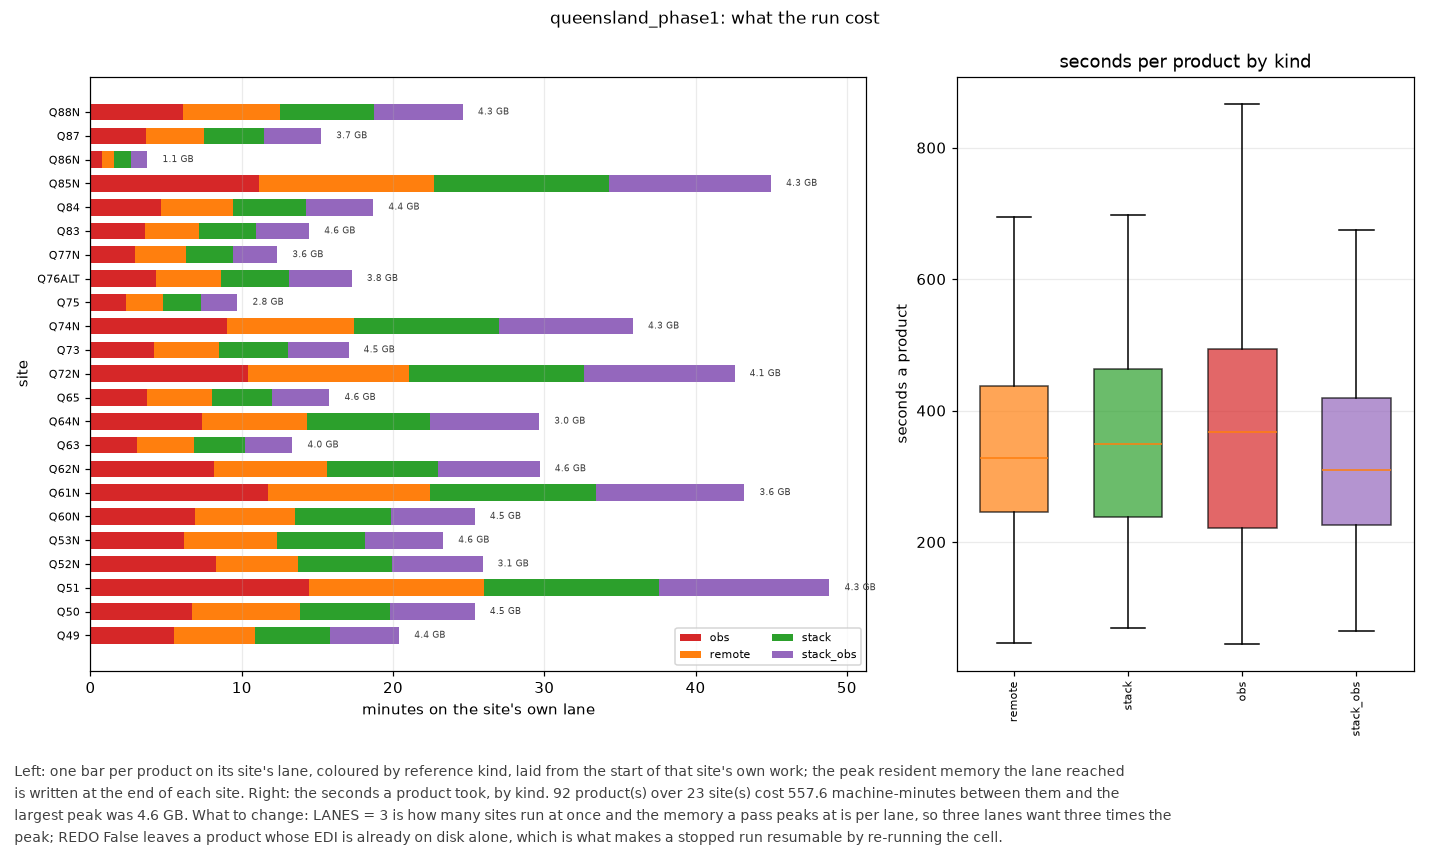

In [22]:
show(FIGP.run_timeline(led, OUT / "03_run.png", lanes=LANES, survey=sv.cfg["name"]))


## A first look

One line per site and kind at 100-1000 s: the two apparent resistivities, the two phases and the tipper
magnitude, read straight out of the EDI. Under it, the remote site against the fleet stack as a ratio at
10-100 s and at 100-1000 s, which is what each reference of the two carries at each end.

This is a reading and not a check. Two kinds that agree over a band are two measurements of the same field
made against different references; a band where they part is a band to look at in workbook 04, whose figures
carry every product of a site on one page.

In [23]:
from mt_metadata.transfer_functions.core import TF

def read_product(path):
    tf = TF(fn=str(path))
    tf.read()
    p = np.asarray(tf.period, float)
    z = np.asarray(tf.impedance, complex)
    t = np.asarray(tf.tipper, complex) if tf.tipper is not None else None
    return p, z, t

def band_read(p, z, t, lo, hi):
    m = (p >= lo) & (p <= hi)
    if not m.any():
        return {}
    out = {}
    for name, (i, j) in (("xy", (0, 1)), ("yx", (1, 0))):
        zz = z[m, i, j]
        good = np.isfinite(zz) & (np.abs(zz) > 0)
        if not good.any():
            continue
        rho = 0.2 * p[m][good] * np.abs(zz[good]) ** 2
        ph = np.degrees(np.angle(zz[good]))
        out["rho_%s" % name] = float(np.median(rho))
        out["phase_%s" % name] = float(np.median(ph))
    if t is not None and np.isfinite(t[m]).any():
        out["tipper"] = float(np.nanmedian(np.abs(t[m]).max(axis=-1)))
    return out

look_rows = []
for r in led.itertuples():
    p_ = Path(str(r.edi))
    if not p_.exists():
        continue
    try:
        per, z, tp = read_product(p_)
        row = dict(site=r.site, kind=r.kind, rate_hz=r.rate_hz, periods=len(per),
                   shortest_s=round(float(np.min(per)), 3), longest_s=round(float(np.max(per)), 1))
        row.update({k: round(v, 3) for k, v in band_read(per, z, tp, 100.0, 1000.0).items()})
        for k, v in band_read(per, z, tp, 10.0, 100.0).items():
            row["%s_10_100" % k] = round(v, 3)
    except Exception as exc:
        row = dict(site=r.site, kind=r.kind, rate_hz=r.rate_hz,
                   note="%s: %s" % (type(exc).__name__, str(exc)[:60]))
    look_rows.append(row)
first = pd.DataFrame(look_rows)
print("the reading at 100-1000 s, per site and kind")
print(first.to_string(index=False))

if "remote" in KINDS and "stack" in KINDS:
    piv = first.pivot_table(index="site", columns="kind",
                            values=["rho_xy", "rho_yx", "rho_xy_10_100", "rho_yx_10_100"])
    ratio_rows = []
    for s in sorted(set(first.site)):
        row = dict(site=s)
        for col, label in (("rho_xy_10_100", "xy 10-100 s"), ("rho_yx_10_100", "yx 10-100 s"),
                           ("rho_xy", "xy 100-1000 s"), ("rho_yx", "yx 100-1000 s")):
            try:
                a = piv.loc[s, (col, "remote")]
                b = piv.loc[s, (col, "stack")]
                row[label] = round(float(a / b), 3) if np.isfinite(a) and np.isfinite(b) and b else np.nan
            except KeyError:
                row[label] = np.nan
        ratio_rows.append(row)
    print()
    print("remote site over fleet stack, as a ratio of apparent resistivity")
    print(pd.DataFrame(ratio_rows).to_string(index=False))


the reading at 100-1000 s, per site and kind
  site      kind  rate_hz  periods  shortest_s  longest_s    rho_xy  phase_xy     rho_yx  phase_yx  tipper  rho_xy_10_100  phase_xy_10_100  rho_yx_10_100  phase_yx_10_100  tipper_10_100
   Q49       obs      1.0       48       2.303    48470.4    62.982    48.095    995.654  -146.023   0.088         63.544           43.439        241.898         -162.303          0.095
   Q49    remote      1.0       41       2.303    12117.6    63.170    46.801   1006.336  -146.417   0.087         58.175           43.335        259.509         -166.352          0.100
   Q49     stack      1.0       48       2.303    48470.4    61.758    46.586   1002.511  -147.641   0.084         49.566           38.481        329.873         -162.611          0.099
   Q49 stack_obs      1.0       48       2.303    48470.4    60.633    46.614   1009.674  -147.465   0.084         52.399           37.979        325.152         -161.827          0.099
   Q50       obs      1.0

The same reading as curves: every kind of the shown site drawn over the others. Look for where the
kinds separate. They usually agree at the short end, where every reference sees the same field, and part
company at the long end, where the observatory reaches furthest and a stack of near members does not. Where
two kinds sit on each other over a band, the band is measured; where they do not, workbook 04's page for the
site is the place to look.

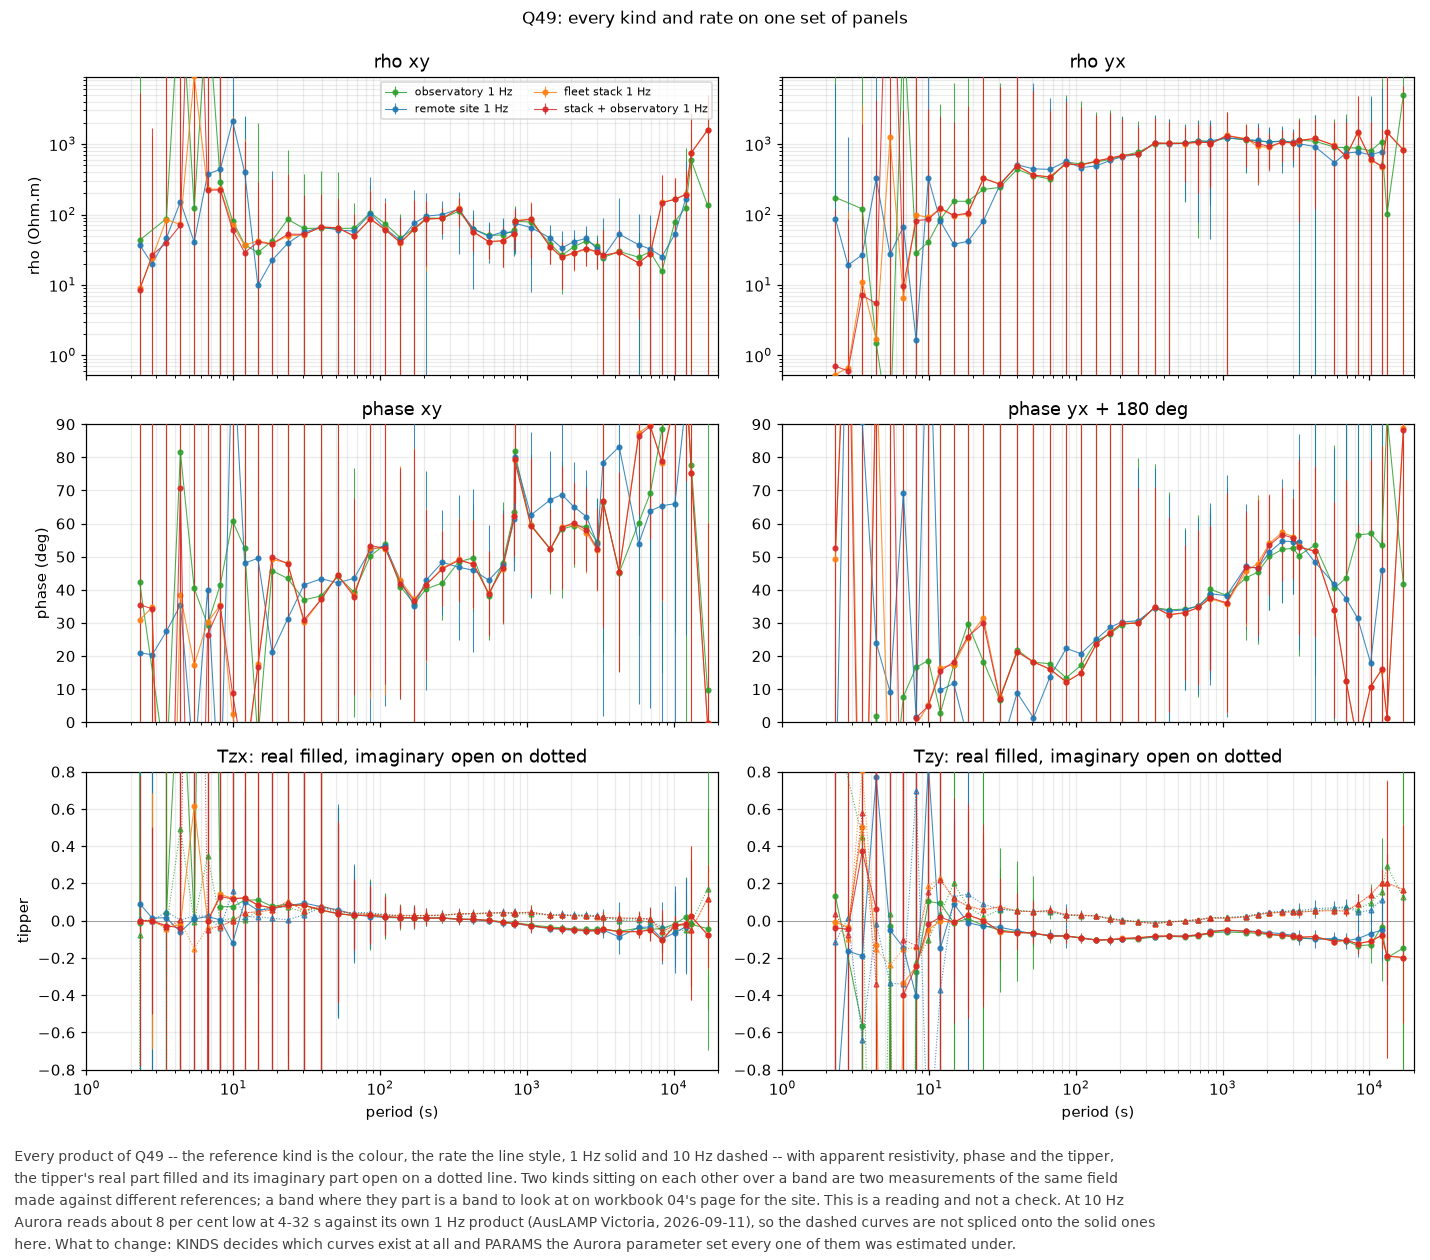

In [24]:
PERIOD_RANGE = (1.0, 20000.0)   # <- the periods the panels draw; the 1 Hz row reaches about 20,000 s

curves = []
for r in led[led.site == SHOW].itertuples():
    p_ = Path(str(r.edi))
    if not p_.exists():
        continue
    try:
        curves.append(("%s %g Hz" % (KIND_WORD[r.kind], r.rate_hz), PR.read_tf(p_),
                       "C%d" % list(KINDS).index(r.kind), "--" if float(r.rate_hz) > 1 else "-"))
    except Exception as exc:
        print("   %s: %s" % (p_.name, exc))
show(FIGP.first_look(curves, SHOW, site_dir(SHOW) / "03_first_look.png", period_range=PERIOD_RANGE))


## The 10 Hz selection

A 10 Hz pass is run on a keep mask of the most coherent hours and never on the whole record. The 10 Hz
product is the short end, below the 16 s join, and no deep level is delivered from it,
so scattered hours cost it nothing: a single Aurora window at the deepest level of the 1 Hz band file is
65,536 s, which no selection of hours could hold, while the 10 Hz band file's own levels sit inside an hour.

Each whole UTC hour is scored on the squared coherence of the two impedance pairs, Ex with Hy and Ey with Hx,
over 1-30 s with a Welch segment of 2,048 samples at 10 Hz and the segment mean removed, as the median over
the band. The two pairs are averaged, and a pair whose electric line is `dead` on that UTC day in workbook
02's `elines` table is left out; an hour holding a non-finite sample scores nothing and is not a candidate.
The series is written to `<work_root>/<site>/hour_scores_10hz.csv`.

`SELECT10` names the fractions taken: the best 5, 10 and 25 per cent of the scored hours, keyed `f05`, `f10`
and `f25`. Beside them a random 25 per cent of the same size is drawn from the same pool under `SEED` and
keyed `r25`, and it is the control: a selection that does not beat its random control bought nothing, and
only the top rows were chosen on the score. The choosing is workbook 05's `select_hours`, so a selection and
its control differ in nothing but how the hours are picked.

A kept hour is 3,600 s, which at 10 Hz is 36,000 samples and exactly the run floor, so an isolated kept hour
survives as one Aurora run and adjacent kept hours merge into one longer run. A kept hour the transient mask
or a gap cuts into falls under the floor and is dropped, which each product's `floor_dropped_frac` reports.

In [25]:
sel_all, NO_CACHE10 = {}, [s for s in CHOSEN if not cached(s, 10)]
for s in [x for x in CHOSEN if x not in NO_CACHE10]:
    t = time.time()
    sel_all[s] = SEL.build(sv, s, rate=10, fractions=SELECT10, seed=SEED)
    print("%-9s %5.1f s  %s" % (s, time.time() - t,
                                " ".join("%s %d h" % (k, v["n_hours"])
                                         for k, v in sorted(sel_all[s].items()))), flush=True)
TAGS10 = [SEL.key_for(f) for f in SELECT10] + ([SEL.key_for(SEL.RANDOM_FRACTION, True)] if SELECT10 else [])
sel_table = SEL.summary_rows(WORK, sorted(sel_all), keys=TAGS10)
print()
print(sel_table.to_string(index=False))
print()
print("the score is the median 1-30 s squared coherence of Ex-Hy and Ey-Hx over each whole UTC hour, Welch "
      "at %d samples; a kept hour is 3600 s = 36000 samples at 10 Hz, which is the run floor"
      % SEL.nperseg_for(10))
if NO_CACHE10:
    print("no 10 Hz cache at %s -- run workbook 02 at 10 Hz over them to bring them into this lane"
          % " ".join(NO_CACHE10))
empty = sorted({r.site for r in sel_table.itertuples() if r.hours_kept == 0})
if empty:
    print("no hour was selected at %s; those sites carry no 10 Hz product and are not requested below"
          % ", ".join(empty))


Q49         0.2 s  f05 73 h f10 146 h f25 364 h r25 364 h


Q50         0.2 s  f05 70 h f10 140 h f25 350 h r25 350 h


Q51         0.2 s  f05 73 h f10 146 h f25 366 h r25 366 h


Q52N        0.2 s  f05 72 h f10 144 h f25 361 h r25 361 h


Q53N        0.2 s  f05 73 h f10 146 h f25 366 h r25 366 h


...

Q85N        0.2 s  f05 73 h f10 146 h f25 364 h r25 364 h


Q86N        0.0 s  f05 14 h f10 29 h f25 72 h r25 72 h

Q87         0.2 s  f05 56 h f10 112 h f25 280 h r25 280 h


Q88N        0.2 s  f05 72 h f10 145 h f25 362 h r25 362 h



  site selection  fraction  random     seed  threshold  hours_scored  hours_kept  days_kept
   Q49       f05      0.05   False 20260916   0.197905          1455          73       3.04
   Q49       f10      0.10   False 20260916   0.106066          1455         146       6.08
   Q49       f25      0.25   False 20260916   0.041979          1455         364      15.17
   Q49       r25      0.25    True 20260916        NaN          1455         364      15.17
   Q50       f05      0.05   False 20260916   0.403764          1401          70       2.92
   Q50       f10      0.10   False 20260916   0.257408          1401         140       5.83
   Q50       f25      0.25   False 20260916   0.077156          1401         350      14.58
   Q50       r25      0.25    True 20260916        NaN          1401         350      14.58
   Q51       f05      0.05   False 20260916   0.850695          1464          73       3.04
   Q51       f10      0.10   False 20260916   0.775368          1464         14

### The run at 10 Hz

One subprocess per site again, `LANES10` of them, each running the two kinds over the four selections: 8
products a site. The observatory is not a kind at 10 Hz. A 5 per cent selection of a 60-day record is about
3 days of 10 Hz and peaks at a few GB where a whole-record pass peaks at 22-37 GB, which is why `LANES10` can
be more than one.

The names carry the selection between the rate and the parameter set,
`<site>_<kind>_10hz_<sel>_<params>.edi`, the ledger gains a `selection` column, the EDI carries a
`selection=` line, and `provenance.json` carries the fraction, the hours kept, the seed and the score
threshold. The 1 Hz names and the 1 Hz path are unchanged.

A workbook run whose `RATES` holds no 10 Hz asks for no product here. The hours are still scored and
selected above, because the score is a property of the record, and the check below scores them.

In [26]:
CHOSEN10 = [s for s in ASK10 if s in sel_all                # the asked-for sites that carry a selected hour
            and max((v["n_hours"] for v in sel_all[s].values()), default=0) > 0]
_s10 = sorted({p.name.split("_", 1)[1] for s in CHOSEN for p in (WORK / s).glob(RUN10 + "_*")
               if p.is_dir()})
STAMP10 = _s10[-1] if _s10 else datetime.now(timezone.utc).strftime("%Y%m%d_%H%M")
l10 = pd.DataFrame(columns=["site", "kind", "rate_hz", "selection", "n_runs", "mask_dropped_frac",
                            "floor_dropped_frac", "seconds", "peak_rss_mb", "status", "error", "edi"])
wall10 = 0.0
if not RATES10 or not CHOSEN10:
    print("RATES = %s and %d site(s) carry a selected hour, so no 10 Hz product is asked for here; the "
          "selections above stand for a run whose RATES holds 10" % (RATES, len(CHOSEN10)))
else:
    t_10 = time.time()
    print("%d site(s) in %d lane(s), %d kind(s) over %d selection(s) at 10 Hz -> %s_%s"
          % (len(CHOSEN10), LANES10, len(KINDS10), max(1, len(TAGS10)), RUN10, STAMP10), flush=True)
    done = 0
    with cf.ThreadPoolExecutor(max_workers=LANES10) as ex:
        for site, rc, secs, out, err in ex.map(
                lambda s: lane(s, RUN10, STAMP10, KINDS10, RATES10, TAGS10), CHOSEN10):
            done += 1
            print("%2d/%2d %-9s exit %d %7.1f s  %s%s" % (done, len(CHOSEN10), site, rc, secs, out,
                                                          ("  || " + err) if rc else ""), flush=True)
    wall10 = time.time() - t_10
    print()
    print("wall time %.1f min over %d sites in %d lanes" % (wall10 / 60.0, len(CHOSEN10), LANES10))

    ledger10 = pd.read_csv(WORK / "survey" / "runs.csv")
    l10 = ledger10[(ledger10["run"].astype(str) == RUN10) & (ledger10["stamp"].astype(str) == STAMP10)
                   & (ledger10.site.isin(CHOSEN10)) & (ledger10.kind.isin(KINDS10))].copy()
    l10["selection"] = l10.selection.astype(str)
    l10["_made"] = (l10.status == "made").astype(int)
    l10 = (l10.sort_values(["site", "kind", "selection", "_made"])
           .drop_duplicates(["site", "kind", "rate_hz", "selection"], keep="last").drop(columns="_made"))
    print()
    print(l10[["site", "kind", "rate_hz", "selection", "n_runs", "mask_dropped_frac",
               "floor_dropped_frac", "seconds", "peak_rss_mb", "status", "error"]].to_string(index=False))
    print()
    print("per selection")
    print(l10.groupby("selection").agg(products=("status", "size"),
                                       made=("status", lambda v: int((v == "made").sum())),
                                       failed=("status", lambda v: int((v == "FAILED").sum())),
                                       runs=("n_runs", "median"), seconds=("seconds", "median"),
                                       peak_rss_mb=("peak_rss_mb", "max")).to_string())


23 site(s) in 2 lane(s), 2 kind(s) over 4 selection(s) at 10 Hz -> sel10_20260917_1200


 1/23 Q49       exit 0     6.5 s  {"site": "Q49", "made": 0, "exists": 8, "failed": 0}


 2/23 Q50       exit 0     6.3 s  {"site": "Q50", "made": 0, "exists": 8, "failed": 0}


 3/23 Q51       exit 0     6.3 s  {"site": "Q51", "made": 0, "exists": 8, "failed": 0}


 4/23 Q52N      exit 0     6.2 s  {"site": "Q52N", "made": 0, "exists": 8, "failed": 0}


...

20/23 Q85N      exit 0     6.0 s  {"site": "Q85N", "made": 0, "exists": 8, "failed": 0}


21/23 Q86N      exit 0     3.4 s  {"site": "Q86N", "made": 0, "exists": 8, "failed": 0}


22/23 Q87       exit 0     6.4 s  {"site": "Q87", "made": 0, "exists": 8, "failed": 0}


23/23 Q88N      exit 0     6.0 s  {"site": "Q88N", "made": 0, "exists": 8, "failed": 0}



wall time 1.2 min over 23 sites in 2 lanes

  site   kind  rate_hz selection  n_runs  mask_dropped_frac  floor_dropped_frac  seconds  peak_rss_mb status  error
   Q49 remote     10.0       f05    18.0            0.96896             0.00389     56.7       8661.3   made    NaN
   Q49 remote     10.0       f10    30.0            0.93701             0.00882     94.0       8661.3   made    NaN
   Q49 remote     10.0       f25    72.0            0.83451             0.01374    225.6       8728.4   made    NaN
   Q49 remote     10.0       r25   208.0            0.80622             0.01775    448.8       9582.4   made    NaN
   Q49  stack     10.0       f05    25.0            0.95488             0.00218     68.0       4758.8   made    NaN
   Q49  stack     10.0       f10    42.0            0.90838             0.00573    112.4       6303.0   made    NaN
   Q49  stack     10.0       f25    89.0            0.77427             0.00825    254.8      11026.9   made    NaN
   Q49  stack     10.0     

### What the 10 Hz row reads against the 1 Hz row

The departure a 10 Hz product carries against its own 1 Hz product is a property of this survey's instrument,
cache and band file, so it is measured here and not quoted from elsewhere. It is measured on the
whole-record 10 Hz products, because those
are the only ones that differ from the 1 Hz row in rate alone; a selection of hours differs in which hours it
holds as well. The 1 Hz row is interpolated in log period and log rho onto the 10 Hz periods inside 4-32 s,
and a 10 Hz period the 1 Hz row does not reach is dropped rather than compared against its end point. The
sentence this cell prints is the one every 10 Hz file of this survey carries.

Under it, the same ratio for each selection product, which is a reading and not a check. A site whose
selections all depart by the same amount is not departing because of the choosing: the ranked selections and
the random control would not agree on a bias the choosing made. Workbook 06's rate gate is what refuses such
a site, on the site's own numbers.

In [27]:
RATE_KIND = "remote"            # <- the kind the rate is measured on; the product of record's own kind
pairs, one_hz = [], {}
for s in CHOSEN:
    a = led.edi[(led.site == s) & (led.kind == RATE_KIND) & (led.rate_hz == 1.0)]
    if not len(a) or not Path(str(a.iloc[0])).exists():
        continue
    one_hz[s] = PR.read_tf(Path(str(a.iloc[0])))
    for d in sorted((WORK / s).glob("*_*")):
        p = d / ("%s_%s_10hz_%s.edi" % (s, RATE_KIND, PARAMS))      # the whole record carries no tag
        if p.exists():
            pairs.append((s, PR.read_tf(p), one_hz[s]))
            break
rate_rec = RATE.measure(pairs, RATE_KIND)
RATE.write_record(WORK, rate_rec)
print("the whole-record 10 Hz %s products of %d site(s), over %g-%g s"
      % (RATE_KIND, rate_rec["n_sites"], rate_rec["band_s"][0], rate_rec["band_s"][1]))
print(pd.DataFrame([dict(site=k, xy_pct=(None if v["xy"] is None else round(100 * (v["xy"] - 1), 1)),
                         yx_pct=(None if v["yx"] is None else round(100 * (v["yx"] - 1), 1)))
                    for k, v in sorted(rate_rec["per_site"].items())]).to_string(index=False))
print()
print("caveat_10hz=%s" % RATE.caveat(rate_rec))

# A product written before this survey was measured carries the sentence of its own day, and remaking a
# whole-record 10 Hz pass to change a sentence costs 22-38 GB and an hour a site. The one header line is
# rewritten in place instead: on the file's bytes, verified after the write to differ from the original in
# that line and nothing else, and recorded in the run folder's provenance.
CAVEAT = RATE.caveat(rate_rec)                  # <- the sentence every 10 Hz product of this survey carries
rw = RATE.rewrite_products(WORK, CAVEAT)
for d in sorted({Path(r["path"]).parent for r in rw if r["changed"]}):
    RATE.record_rewrite(d, [r for r in rw if Path(r["path"]).parent == d])
done_rw = [r for r in rw if r["changed"]]
already = [r for r in rw if not r["changed"] and "already carries" in r["reason"]]
refused = [r for r in rw if not r["changed"] and "already carries" not in r["reason"]]
print()
print("the caveat line, rewritten in place: %d file(s) changed, %d already carried it, %d refused"
      % (len(done_rw), len(already), len(refused)))
for r in refused[:8]:
    print("   refused %-58s %s" % (Path(r["path"]).name, r["reason"]))
if done_rw:
    print("   the sentence they carried before: %s" % sorted({r["old"] for r in done_rw})[0][:150])

sel_dep = []
for s in sorted(sel_all):
    if s not in one_hz:
        continue
    for tag in TAGS10:
        for k in KINDS10:
            p = WORK / s / ("%s_%s" % (RUN10, STAMP10)) / ("%s_%s_10hz_%s_%s.edi" % (s, k, tag, PARAMS))
            if not p.exists():
                continue
            d = RATE.departure(PR.read_tf(p), one_hz[s]) if k == RATE_KIND else None
            if d is None:
                continue
            sel_dep.append(dict(site=s, kind=k, selection=tag,
                                xy_pct=round(100 * (d["xy"] - 1), 1) if np.isfinite(d["xy"]) else None,
                                yx_pct=round(100 * (d["yx"] - 1), 1) if np.isfinite(d["yx"]) else None))
dep = pd.DataFrame(sel_dep)
if len(dep):
    print()
    print("each %s selection product against the same site's 1 Hz product, per cent over %g-%g s"
          % (RATE_KIND, rate_rec["band_s"][0], rate_rec["band_s"][1]))
    print(dep.pivot_table(index="site", columns="selection",
                          values=["xy_pct", "yx_pct"]).round(1).to_string())
    wide = dep.groupby("site").agg(worst=("xy_pct", lambda v: max(abs(x) for x in v if x is not None)),
                                   n=("selection", "size"))
    far = wide[wide.worst > 20]
    print()
    print("sites whose every selection departs by more than 20 per cent on one component: %s"
          % (", ".join("%s (worst %.0f %%, %d selection(s))" % (r.Index, r.worst, r.n)
                       for r in far.itertuples()) or "none"))


the whole-record 10 Hz remote products of 5 site(s), over 4-32 s
site  xy_pct  yx_pct
Q60N    -2.6    -1.3
Q61N    -2.4     1.4
 Q73    -2.1     0.1
Q74N    -2.1     0.4
 Q83    -1.3     0.1

caveat_10hz=Aurora at 10 Hz reads xy -2.1 per cent and yx +0.1 per cent at 4-32 s against its own 1 Hz product, measured on this survey's 5 whole-record 10 Hz remote product(s); not spliced

the caveat line, rewritten in place: 0 file(s) changed, 195 already carried it, 0 refused



each remote selection product against the same site's 1 Hz product, per cent over 4-32 s
              xy_pct                          yx_pct                       
selection        f05        f10    f25   r25     f05      f10    f25    r25
site                                                                       
Q49             68.7       30.6   60.1  12.6   -71.3    -30.3  -73.4  118.8
Q50             -0.4       -1.0   -1.3  -3.8   -18.3     -3.8   -0.5   -2.0
Q51             16.4        9.8    2.9   4.3   -10.8     -1.2    2.8   -0.4
Q52N            -0.2        2.6   -3.0  -4.6   -11.9     -8.8   -5.7   -1.1
Q53N            -5.0       -4.2   -5.3  -4.5     1.1     -1.7   -1.6   -2.7
Q60N             1.2        0.8   -1.6  -3.0    -3.2     -2.0   -1.3   -1.7
Q61N            -1.2       -2.2   -1.4  -2.5     2.1      3.4   -2.2   -0.7
Q62N            -6.0       -5.4   -4.8  -3.9    -1.2     -0.4    2.1    1.7
Q63             -1.0        0.1   -0.7  -5.8    -2.5     -3.7   -1.1   -1.

**This check fails if a selected hour does not begin on a whole UTC hour, is not exactly 3,600 s
or falls outside the record it was selected from, if a ranked selection and its random control do not keep the
same number of hours, if the ranked thresholds do not fall as the fraction rises, if any requested 10 Hz
selection product is missing or FAILED, carries the wrong selection in its ledger row, or does not name that
selection in its own EDI, if any 10 Hz product carries a caveat other than the survey's measured sentence,
if any ledger row claiming a product names a file that is not on disk, or if any ledger row belongs to a run
folder that is not on disk.**

The file limb is `made` and `exists` rows only. A `FAILED` row names the product its pass set out to write
and did not, which is the record that the attempt was made and what broke it; it is counted and named in the
cell so it is not hidden, and it is not a row claiming a product. The run-folder limb is every row whatever
its status: a run folder that is not on disk left no product, no log and no provenance, so a row pointing
into one describes nothing at all.

The first three limbs are scored against the cache each selection was made from -- its own `t0` and sample
count, read off the npz -- and not against the selection file's own statement of itself. The product limbs are
scored over every site with at least one selected hour, times `KINDS10`, times the tags; a workbook run whose
`RATES` holds no 10 Hz asks for no product and those limbs score nothing, which the verdict says. The EDI limb
reads the `selection=` line out of each written file, which is an observable independent of the ledger row
beside it: the ledger is what the run said it did and the file is what it wrote. The caveat limb reads every
10 Hz product on disk, not only the ones this run asked for, because a product written before the survey's
departure was measured carries the sentence of its own day until the rewrite reaches it.

In [28]:
def span10(site):
    """(t0, the number of samples) of one site's 10 Hz cache, read off the npz header alone."""
    z = np.load(WORK / "cache_10hz" / ("%s.npz" % site), allow_pickle=False)
    t0z, nz = int(z["t0"][0]), int(len(z["Hx"]))
    z.close()
    return t0z, nz

bad_hour, bad_count, bad_order, n_hours_scored = [], [], [], 0
for s in sorted(sel_all):
    t0h, nh = span10(s)
    t_end = t0h + nh / 10.0
    thr = []
    for tag in TAGS10:
        item = sel_all[s].get(tag) or {}
        for ta, tb in item.get("hours", []):
            n_hours_scored += 1
            if ta % 3600 or (tb - ta) != 3600 or ta < t0h or tb > t_end:
                bad_hour.append("%s %s %d-%d" % (s, tag, ta, tb))
        if not tag.startswith("r") and item.get("threshold") is not None:
            thr.append((item["fraction"], float(item["threshold"])))
        if tag.startswith("r"):
            ranked = sel_all[s].get(SEL.key_for(SEL.RANDOM_FRACTION)) or {}
            if ranked and ranked.get("n_hours") != item.get("n_hours"):
                bad_count.append("%s %s %d h against %s %d h"
                                 % (s, SEL.key_for(SEL.RANDOM_FRACTION), ranked.get("n_hours"), tag,
                                    item.get("n_hours")))
    thr.sort()
    if any(b[1] > a[1] for a, b in zip(thr, thr[1:])):
        bad_order.append("%s %s" % (s, " ".join("%.0f%%:%.3f" % (100 * f, v) for f, v in thr)))

want10 = [(s, k, t) for s in CHOSEN10 for k in KINDS10 for t in TAGS10
          if sel_all[s].get(t, {}).get("n_hours", 0) > 0] if RATES10 else []
have10 = {(r.site, r.kind, str(r.selection)): r for r in l10.itertuples()}
missing10, no_line, wrong_row = [], [], []
for w in want10:
    r = have10.get(w)
    if r is None or str(r.status) == "FAILED":
        missing10.append(w)
        continue
    p_ = Path(str(r.edi))
    if not p_.exists():
        missing10.append(w)
        continue
    if str(r.selection) != w[2]:
        wrong_row.append("%s %s %s -> %s" % (w[0], w[1], w[2], r.selection))
    said = EDI.read_parameter(p_, "selection")
    if not said.startswith(w[2]):
        no_line.append("%s %s %s: %s" % (w[0], w[1], w[2], said[:60] or "no selection= line"))
no_control = sorted({s for s, k, t in want10 if not t.startswith("r")
                     and (s, k, SEL.key_for(SEL.RANDOM_FRACTION, True)) not in have10})
# every 10 Hz product on disk, not only the ones this run asked for: one written before the survey was
# measured carries the sentence of its own day until the rewrite above reaches it
ten = sorted(WORK.glob("*/*/*_10hz_*.edi"))
n_ten = len(ten)
stale_caveat = [p.name for p in ten if not RATE.carries_caveat(p, CAVEAT)]
# the whole ledger against the disk: a row that says a product was made or is on disk has to name a file
# that is there. A FAILED row names the product its pass set out to write and did not, so it is counted and
# named rather than scored.
whole_led = pd.read_csv(WORK / "survey" / "runs.csv")
claims = whole_led[whole_led.status.isin(["made", "exists"])]
orphan_rows = ["%s %s %s %s %g Hz %s" % (r.site, r.run, r.stamp, r.kind, r.rate_hz, r.selection)
               for r in claims.itertuples() if not Path(str(r.edi)).exists()]
failed_rows = int((whole_led.status == "FAILED").sum())
# the second clause, on every row whatever its status: a row belongs to a run, and a run that is not on
# disk left no product, no log and no provenance, so its rows describe nothing
homeless_rows = sorted({"%s %s_%s" % (r.site, r.run, r.stamp) for r in whole_led.itertuples()
                        if not (WORK / str(r.site) / ("%s_%s" % (r.run, r.stamp))).is_dir()})
failed10 = l10[l10.status == "FAILED"] if len(l10) else l10
cost10 = l10[l10.seconds.notna()] if len(l10) else l10
print()
print("%d selected hour(s) over %d site(s) scored against their own cache; %d product(s) requested; %d "
      "10 Hz product(s) on disk scored on their caveat; %d ledger row(s) claiming a product scored against "
      "the disk and all %d scored on their run folder, beside %d FAILED row(s) that claim no product"
      % (n_hours_scored, len(sel_all), len(want10), n_ten, len(claims), len(whole_led), failed_rows))
if not n_hours_scored:
    print("VERDICT: UNJUDGED -- no hour was selected at any site, so nothing was scored")
elif bad_hour or bad_count or bad_order or missing10 or len(failed10) or no_line or wrong_row         or no_control or stale_caveat or orphan_rows or homeless_rows:
    print("VERDICT: FAIL -- %d selected hour(s) are not a whole UTC hour of 3600 s inside their record (%s); "
          "%d site(s) draw a control of a different size (%s); %d site(s) order their thresholds wrongly "
          "(%s); %d of %d requested products are missing (%s); %d are FAILED (%s); %d carry no matching "
          "selection= line in the EDI (%s); %d carry the wrong selection in the ledger row (%s); %d site(s) "
          "carry a ranked selection with no random control (%s); %d of %d 10 Hz product(s) on disk carry a "
          "caveat that is not the survey's measured sentence (%s); %d of %d ledger row(s) claiming a "
          "product name a file that is not on disk (%s); %d run folder(s) the ledger has rows for are not "
          "on disk (%s)"
          % (len(bad_hour), "; ".join(bad_hour[:6]) or "none",
             len(bad_count), "; ".join(bad_count[:4]) or "none",
             len(bad_order), "; ".join(bad_order[:4]) or "none",
             len(missing10), len(want10), "; ".join("%s %s %s" % m for m in missing10[:8]) or "none",
             len(failed10), "; ".join("%s %s %s: %s" % (r.site, r.kind, r.selection, str(r.error)[:70])
                                      for r in failed10.itertuples()) or "none",
             len(no_line), "; ".join(no_line[:6]) or "none",
             len(wrong_row), "; ".join(wrong_row[:6]) or "none",
             len(no_control), ", ".join(no_control[:8]) or "none",
             len(stale_caveat), n_ten, "; ".join(stale_caveat[:6]) or "none",
             len(orphan_rows), len(claims), "; ".join(orphan_rows[:6]) or "none",
             len(homeless_rows), "; ".join(homeless_rows[:6]) or "none"))
else:
    print("VERDICT: PASS -- all %d selected hour(s) over %d site(s) are whole 3600 s UTC hours inside their "
          "own record, every control keeps the same number of hours as its ranked selection, every site's "
          "thresholds fall as the fraction rises, every one of the %d 10 Hz products on disk carries the "
          "survey's own measured caveat, all %d ledger rows claiming a product name a file that is there, "
          "and every one of the %d rows belongs to a run folder that is on disk; %s"
          % (n_hours_scored, len(sel_all), n_ten, len(claims), len(whole_led),
             ("no 10 Hz product was requested (RATES = %s), so no product was scored" % RATES)
             if not want10 else
             ("all %d requested products over %d site(s), %d kind(s) and the tags %s exist and none is "
              "FAILED, every one names its selection in its ledger row and in its own EDI, every ranked "
              "selection has its random control beside it, and the %d of them whose cost the ledger "
              "records hold %d to %d Aurora run(s) each, took %.1f to %.1f s and peaked at %.1f GB in one "
              "lane"
              % (len(want10), len(CHOSEN10), len(KINDS10), ", ".join(TAGS10), len(cost10),
                 int(cost10.n_runs.min()), int(cost10.n_runs.max()), cost10.seconds.min(),
                 cost10.seconds.max(), cost10.peak_rss_mb.max() / 1024.0))))



20148 selected hour(s) over 23 site(s) scored against their own cache; 184 product(s) requested; 195 10 Hz product(s) on disk scored on their caveat; 1534 ledger row(s) claiming a product scored against the disk and all 1534 scored on their run folder, beside 0 FAILED row(s) that claim no product
VERDICT: PASS -- all 20148 selected hour(s) over 23 site(s) are whole 3600 s UTC hours inside their own record, every control keeps the same number of hours as its ranked selection, every site's thresholds fall as the fraction rises, every one of the 195 10 Hz products on disk carries the survey's own measured caveat, all 1534 ledger rows claiming a product name a file that is there, and every one of the 1534 rows belongs to a run folder that is on disk; all 184 requested products over 23 site(s), 2 kind(s) and the tags f05, f10, f25, r25 exist and none is FAILED, every one names its selection in its ledger row and in its own EDI, every ranked selection has its random control beside it, and t

The selection and what it produced. In the upper panel the score runs over the record with the
selections drawn above it as rows of spans, each named at the right: look at whether the chosen hours cluster
in a few active days or scatter through the record, and at how far the `f05` threshold stands above the `f25`
one. The top row, `r25`, is the random control and costs exactly the same number of hours as `f25`.

In the lower panels the four selections are drawn dashed against the 1 Hz product of the same kind, solid.
Look first at the short end, below the marked join, which is the only part of the 10 Hz product a splice would
ever use, and at whether the ranked selections sit closer to the 1 Hz curve than the random control does. Over
4-32 s the 10 Hz row departs from the 1 Hz row by the rate's own figure, printed in the section above,
whatever the selection, so an offset in that band is the rate and not the choosing.

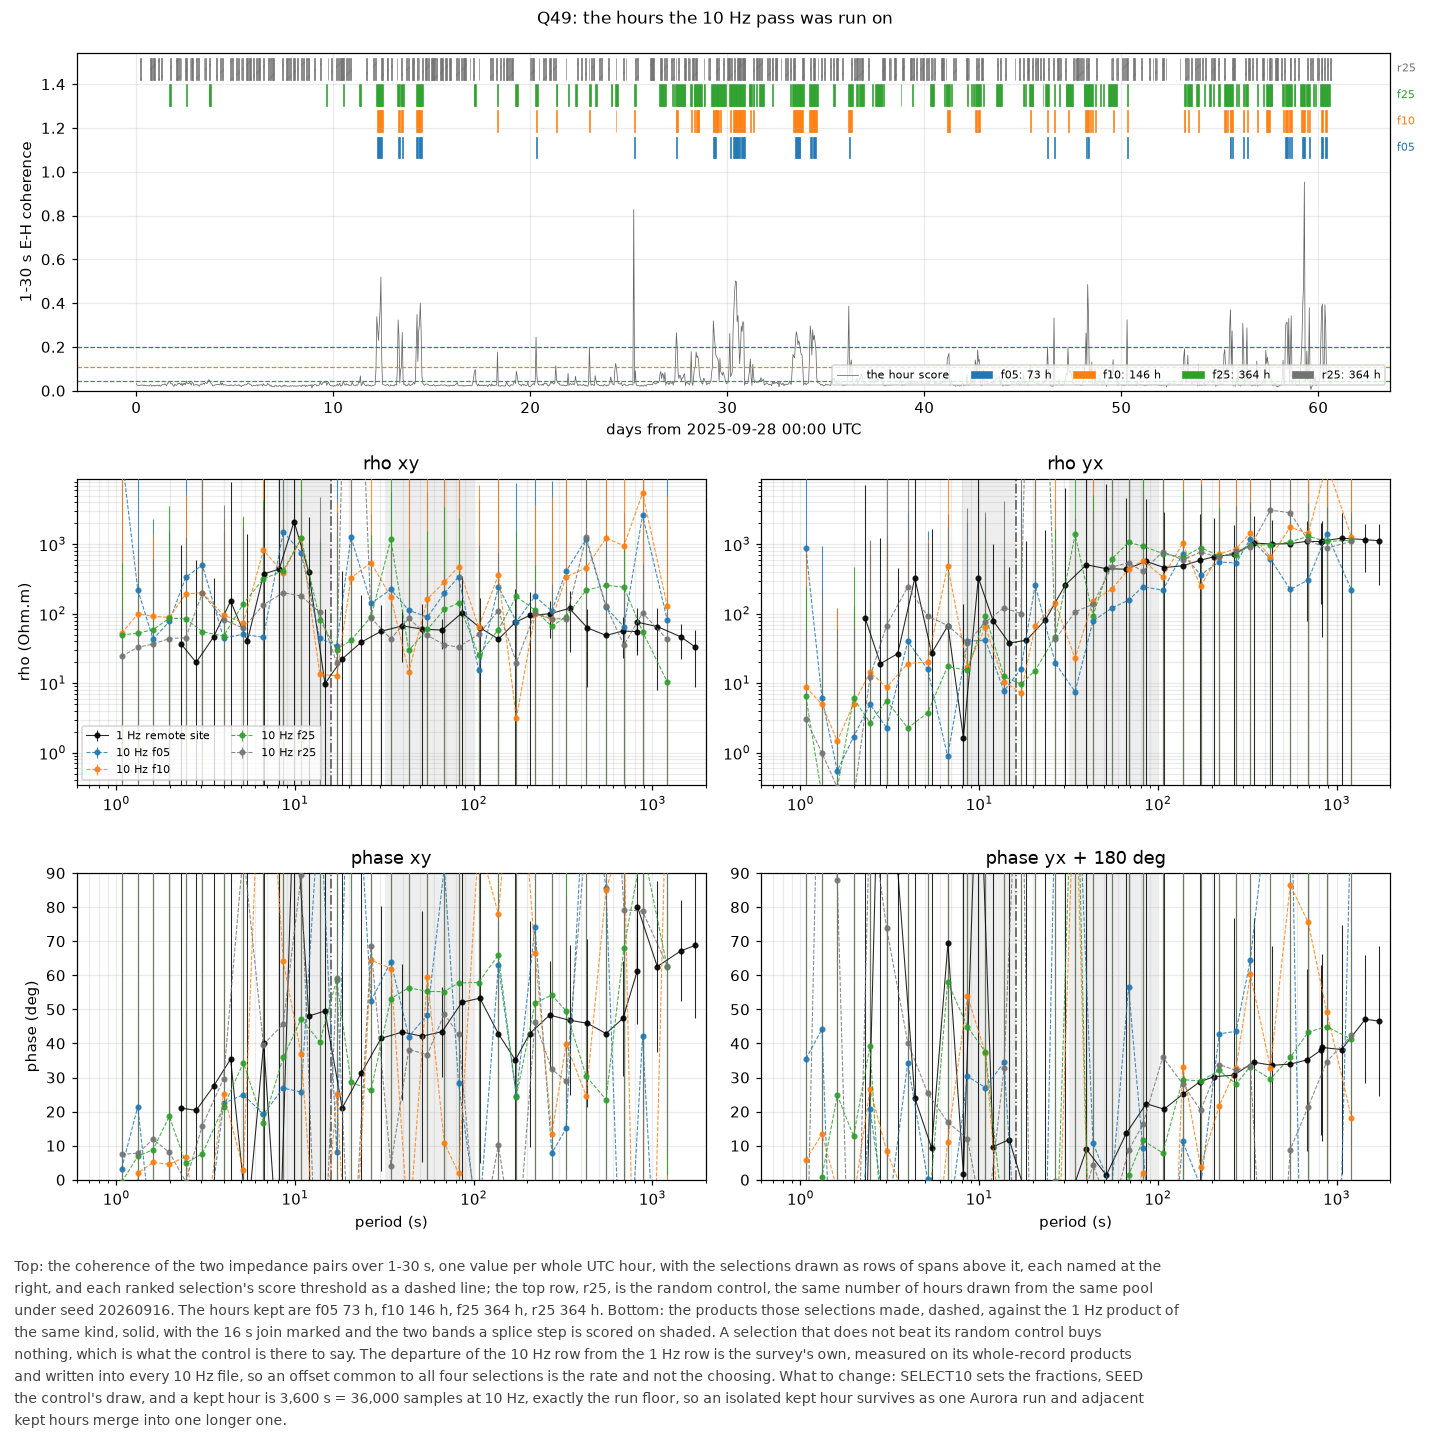

In [29]:
KIND10_SHOW = "remote" if "remote" in KINDS10 else KINDS10[0]   # <- the kind the selections are drawn for
sel_curves = []
base = led.edi[(led.site == SHOW) & (led.kind == KIND10_SHOW) & (led.rate_hz == 1.0)]
if len(base) and Path(str(base.iloc[0])).exists():
    sel_curves.append(("1 Hz %s" % KIND_WORD[KIND10_SHOW], PR.read_tf(Path(str(base.iloc[0]))), "k", "-"))
for j, tag in enumerate(TAGS10):
    row = l10[(l10.site == SHOW) & (l10.kind == KIND10_SHOW) & (l10.selection == tag)]
    if not len(row) or not Path(str(row.edi.iloc[0])).exists():
        continue
    sel_curves.append(("10 Hz %s" % tag, PR.read_tf(Path(str(row.edi.iloc[0]))),
                       "0.45" if tag.startswith("r") else "C%d" % j, "--"))
why10 = ("the 10 Hz pass was not run for this site: RATES holds no 10 Hz" if not RATES10 else
         ("the 10 Hz pass was not run for this site: SITES10 = %r does not name it" % SITES10
          if SHOW not in CHOSEN10 else
          "the 10 Hz pass was run for this site but wrote no product of this kind"))
show(FIGP.hour_selection(SEL.site_scores(sv, SHOW), sel_all[SHOW], sel_curves, SHOW,
                         site_dir(SHOW) / "03_selection_10hz.png",
                         join_s=float((sv.cfg.get("bands") or {}).get("splice_join_s", 16)),
                         band_s=SEL.SCORE_BAND_S, seed=SEED, no_ten_hz=why10))


## What was written

In [30]:
rows = []
run_dirs = [WORK / s / ("%s_%s" % (RUN, STAMP)) for s in CHOSEN]
run_dirs += [WORK / s / ("%s_%s" % (RUN10, STAMP10)) for s in CHOSEN]
for d in run_dirs:
    for p in sorted(d.glob("*")):
        if p.is_file():
            rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
for rate in RATES:
    for p in sorted((WORK / "references" / ("%dhz" % rate)).glob("*")):
        rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
for p in sorted(TR.tails_dir(WORK).glob("*.npz")):
    rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
for s in CHOSEN:
    for name in (SEL.SCORES_NAME, SEL.SELECTION_NAME):
        p = WORK / s / name
        if p.exists():
            rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
for p in list(WRITTEN) + [WORK / "survey" / "runs.csv"]:
    if Path(p).exists():
        rows.append(dict(file=str(p), kb=round(Path(p).stat().st_size / 1024, 1)))
files = pd.DataFrame(rows).drop_duplicates("file").sort_values("file")
print("%d files, %.1f MB" % (len(files), files.kb.sum() / 1024))
print(files.head(60).to_string(index=False))
if len(files) > 60:
    print("   ... and %d more" % (len(files) - 60))
print()
print("the %d figure(s) this workbook drew" % len(WRITTEN))
for p in WRITTEN:
    print("   %-64s %8.1f KB" % (str(p), Path(p).stat().st_size / 1024))
print()
d = run_dirs[0]
print("the run folder of %s" % CHOSEN[0])
for p in sorted(d.glob("*")):
    print("   %-52s %8.1f KB" % (p.name, p.stat().st_size / 1024))
print()
print("the first 30 processing_parameters lines of one EDI")
one = sorted(d.glob("*.edi"))
if one:
    txt = one[0].read_text(encoding="utf-8", errors="ignore")
    keep_lines = [ln.strip() for ln in txt.splitlines()
                  if "=" in ln and not ln.strip().startswith(">")]
    print(one[0].name)
    for ln in keep_lines[:30]:
        print("   %s" % ln[:160])
print()
print("the selection line of one 10 Hz product")
sel_one = sorted((WORK / SHOW / ("%s_%s" % (RUN10, STAMP10))).glob("*.edi"))
if sel_one:
    print(sel_one[0].name)
    for ln in sel_one[0].read_text(encoding="utf-8", errors="ignore").splitlines():
        if ln.strip().startswith(("selection=", "runs=", "caveat_10hz=")):
            print("   %s" % ln.strip()[:200])


1028 files, 23737.8 MB
                                                                                                                 file    kb
                                      E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\03_first_look.png 451.7
                                           E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\03_frame.png 107.7
                                            E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\03_mask.png 178.2
                                          E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\03_remote.png 100.5
                                  E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\03_selection_10hz.png 534.8
                                           E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\03_stack.png 186.2
        E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase1\Q49\first_20260916_1054\Q49_obs_1hz_kaiser2